In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import itertools
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import scipy.stats as stats

sns.set(font_scale=2) 
sns.set_style("ticks")
import warnings
warnings.filterwarnings("ignore")

In [30]:
def preprocess_plot(df, cat_name , name, plotting = True):
    ls = ['Cm(pF)', 'Firing_freq_(Hz)_I0','Instant_freq_(Hz)', 'isi_(ms)',  'CaT',  'Ih_at_-120mV', 'AP_ampl', 'AP_halfwidth', 'AP_time_to_peak','area(mV_ms)', 'rheobase_at_-60mV_(pA)', 'AHP_(mV)', 'Vm',
       'Input_Resistance', 'sPSC_frequency', 'sPSC_Amplitude(pA)','sPSCs_Rise time', 'sPSCs (decay)']

    for column in ls:
        df[column] = pd.to_numeric(df[column])

        if column in ['isi_(ms)', 'AP_ampl', 'AP_halfwidth', 'AP_time_to_peak','area(mV_ms)', 'AHP_(mV)']:
            param_df = df[df.I_zero != 'silent']
        
        # _, p = stats.ttest_ind(df[(df['Behaviour_6hFD'] == 'Pre')][column].dropna(),
        #                             df[df['Behaviour_6hFD'] == 'Post'][column].dropna(),
        #                             equal_var = True)
        else:
            param_df = df
        
        try:
            unique_cat = df[cat_name].unique()
            combos = list(itertools.combinations(unique_cat, 2))

            for combo in combos:

                _, p = stats.mannwhitneyu(param_df[(param_df[cat_name] == combo[0])][column].dropna(),
                                        param_df[(param_df[cat_name] == combo[1])][column].dropna())
            
                print(column, combo, p)

           
        except ValueError:
            
            continue

        if plotting:
            try:
                print(param_df.groupby(cat_name)[column].mean())
                
                fig,ax = plt.subplots(figsize = (3,3))
            
                sns.swarmplot(x=cat_name, y =column, data= param_df, palette = ['darkgray', '#F97306'], alpha = 1, size = 3)
                sns.boxplot(x=cat_name, y =column, data= param_df, palette = ['darkgray', '#F97306'], boxprops=dict(alpha=0.7), width = 0.5)
                sns.despine()
                plt.title(column, pad = 20)
                plt.xticks(rotation = 90)
                plt.savefig(f'output_figures/{name}_{column}.png',dpi = 300, bbox_inches = 'tight')
                plt.show()
            except KeyError:
                pass
                

def proportion(df, column1, column2, cols):
    prop = pd.crosstab(df[column1], df[column2], margins = True).reset_index()
    prop = prop.set_index(column1)
    print(prop)
    prop = prop.iloc[:-1, :-1]
    stat, p, dof, expected  = stats.chi2_contingency(prop)
    print(p)
    
    prop = prop.apply(lambda x: x.div(x.sum()).mul(100), axis=1)
    
    
    prop = prop[cols]
    prop = prop.reset_index()
    return prop

def prop_plot(df, column):
    df.plot(x = column, 
              kind = 'bar', 
              stacked = True,  
              mark_right = False,
              color = ['black', 'darkgray','gray'],
              figsize = (3,5), alpha = 0.7)
    plt.xticks(rotation = 0)
    ax = plt.gca()
    plt.ylabel('Percentage (%)')
    plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)

def remove_outlier(df_in, col_name):
    q1 = df_in[col_name].quantile(0.25)
    q3 = df_in[col_name].quantile(0.75)
    iqr = q3-q1 #Interquartile range
    fence_low  = q1-1.5*iqr
    fence_high = q3+1.5*iqr
    df_out = df_in.loc[(df_in[col_name] > fence_low) & (df_in[col_name] < fence_high)]
    return df_out

# epnys analysis

In [40]:
ls = ['Cm(pF)', 'Firing_freq_(Hz)_I0','Instant_freq_(Hz)', 'isi_(ms)',  'CaT',  'Ih_at_-120mV', 'AP_ampl', 'AP_halfwidth', 'AP_time_to_peak','area(mV_ms)', 'rheobase_at_-60mV_(pA)', 'AHP_(mV)', 'Vm',
       'Input_Resistance', 'sPSC_frequency', 'sPSC_Amplitude(pA)','sPSCs_Rise time', 'sPSCs (decay)']

df = pd.read_csv('ephys_analysis_MC.csv')
df['experiment_day'] = df['experiment_day'].apply(lambda x: str(x).upper()[:13])
df.loc[df.Behaviour_6hFD =='No_FD','Behaviour_6hFD'] = 'Pre'
# df.loc[df.Behaviour_6hFD =='Agg+','Behaviour_6hFD'] = 'Post'
df.rename(columns = {'Instant_freq_(Hz)_1/ISI':'Instant_freq_(Hz)'}, inplace =True)

cat = df.Behaviour_6hFD.unique()

gal = df[df.Gal_positive == 'yes']
no_gal = df[df.Gal_positive == 'no']
ephys = df[df.Gal_positive.isin(['Unknown', 'no'])]
ephys = pd.concat([df[(df.Gal_positive.isin(['Unknown','no']) & (df.Behaviour_6hFD == 'Pre'))], df[df.Behaviour_6hFD.isin(cat)]])
sample_num= int(no_gal.shape[0]/4)
ephys = pd.concat([ephys, gal.sample(n = sample_num, random_state = 859)]).reset_index(drop = True)
ephys.loc[ephys.Behaviour_6hFD.isin(['npy_10', 'npy_100']),'Behaviour_6hFD'] = 'npy'

ephys.to_csv('sampled_ephys_data.csv')

In [4]:
ephys.Behaviour_6hFD.unique()

array(['Pre', 'Agg+', 'Agg-', 'npy_antag', 'npy_10_paired', 'npy',
       'npy_100_paired', 'agrp_100_paired', 'agrp_100', 'ZD7288'],
      dtype=object)

## all properties

Cm(pF) ('Pre', 'Agg+') 0.13451684745243198
Firing_freq_(Hz)_I0 ('Pre', 'Agg+') 0.009987674731723671
Firing_freq_(Hz)_I0 ('Pre', 'Agg-') 0.06990396098910674
Firing_freq_(Hz)_I0 ('Pre', 'npy') 0.24743356072065226
Firing_freq_(Hz)_I0 ('Pre', 'agrp_100') 0.7823911665890277
Firing_freq_(Hz)_I0 ('Agg+', 'Agg-') 0.001187420736180105
Firing_freq_(Hz)_I0 ('Agg+', 'npy') 0.8977817549286622
Firing_freq_(Hz)_I0 ('Agg+', 'agrp_100') 0.24978918715317577
Firing_freq_(Hz)_I0 ('Agg-', 'npy') 0.030743009764918127
Firing_freq_(Hz)_I0 ('Agg-', 'agrp_100') 0.0967416980408013
Firing_freq_(Hz)_I0 ('npy', 'agrp_100') 0.2868997552229626
Behaviour_6hFD
Agg+        0.851379
Agg-        2.212273
Pre         1.701674
agrp_100    0.782857
npy         0.246000
Name: Firing_freq_(Hz)_I0, dtype: float64


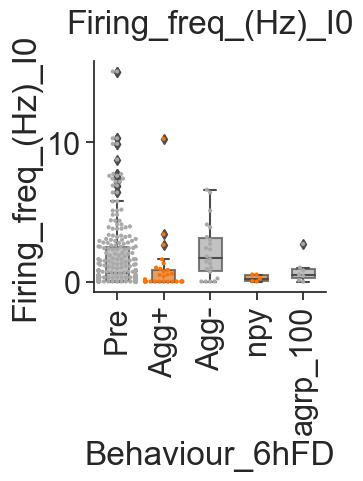

Instant_freq_(Hz) ('Pre', 'Agg+') 0.006874220766097158
Instant_freq_(Hz) ('Pre', 'Agg-') 0.17103440424548122
Instant_freq_(Hz) ('Pre', 'npy') 0.20364362673676117
Instant_freq_(Hz) ('Pre', 'agrp_100') 0.6523626656140611
Instant_freq_(Hz) ('Agg+', 'Agg-') 0.0028015314202355815
Instant_freq_(Hz) ('Agg+', 'npy') 0.8572706001605277
Instant_freq_(Hz) ('Agg+', 'agrp_100') 0.20174695249389074
Instant_freq_(Hz) ('Agg-', 'npy') 0.041773536033718243
Instant_freq_(Hz) ('Agg-', 'agrp_100') 0.13162211786432693
Instant_freq_(Hz) ('npy', 'agrp_100') 0.28860919043778466
Behaviour_6hFD
Agg+        1.104483
Agg-        2.549545
Pre         2.091240
agrp_100    1.107143
npy         0.480000
Name: Instant_freq_(Hz), dtype: float64


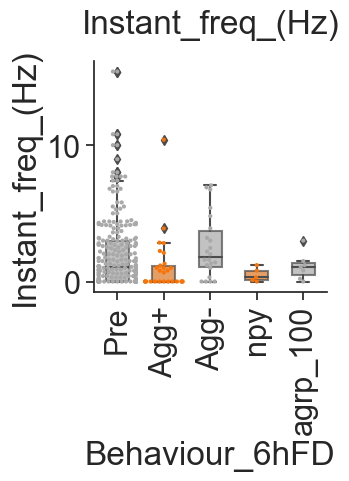

isi_(ms) ('Pre', 'Agg+') 0.6907649348388157
isi_(ms) ('Pre', 'Agg-') 0.06205349931476427
isi_(ms) ('Pre', 'npy') 0.04998542751765637
isi_(ms) ('Pre', 'agrp_100') 0.2891763801104621
isi_(ms) ('Agg+', 'Agg-') 0.02380771805731315
isi_(ms) ('Agg+', 'npy') 0.034640522875816995
isi_(ms) ('Agg+', 'agrp_100') 0.49396284829721365
isi_(ms) ('Agg-', 'npy') 0.0010936431989063567
isi_(ms) ('Agg-', 'agrp_100') 0.014799845463461024
isi_(ms) ('npy', 'agrp_100') 0.17142857142857143
Behaviour_6hFD
Agg+        1539.244286
Agg-         748.955556
Pre         3418.644389
agrp_100    3142.500000
npy         8629.625000
Name: isi_(ms), dtype: float64


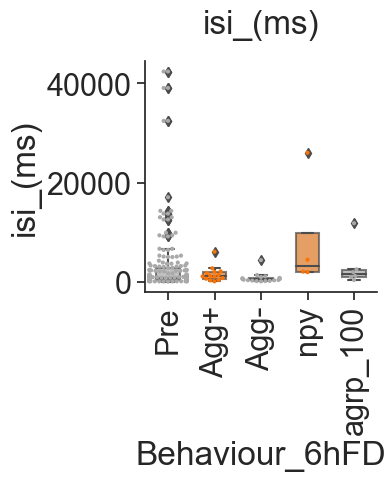

CaT ('Pre', 'Agg+') 0.1712124050690772
CaT ('Pre', 'Agg-') 0.6526978717444164
CaT ('Pre', 'npy') 0.249617513501052
CaT ('Pre', 'agrp_100') 0.031744693929577183
CaT ('Agg+', 'Agg-') 0.13367693756507826
CaT ('Agg+', 'npy') 0.73295513208869
CaT ('Agg+', 'agrp_100') 0.14806887661080173
CaT ('Agg-', 'npy') 0.17845487224685097
CaT ('Agg-', 'agrp_100') 0.017974675359695533
CaT ('npy', 'agrp_100') 0.3104944343172349
Behaviour_6hFD
Agg+        4.638889
Agg-        5.747273
Pre         6.425361
agrp_100    0.000000
npy         1.460000
Name: CaT, dtype: float64


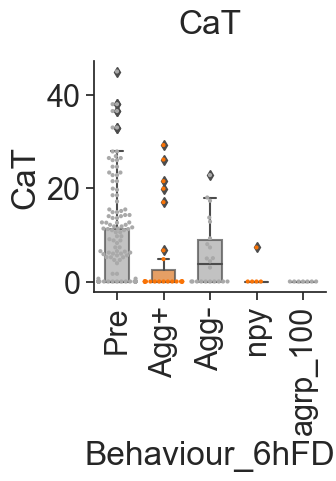

Ih_at_-120mV ('Pre', 'Agg+') 0.009430439383629686
Ih_at_-120mV ('Pre', 'Agg-') 0.44291348399305963
Ih_at_-120mV ('Pre', 'npy') 0.028738061181081277
Ih_at_-120mV ('Pre', 'agrp_100') 0.013524190402116058
Ih_at_-120mV ('Agg+', 'Agg-') 0.0009457519321693969
Ih_at_-120mV ('Agg+', 'npy') 0.21521908936144574
Ih_at_-120mV ('Agg+', 'agrp_100') 0.1720005161758391
Ih_at_-120mV ('Agg-', 'npy') 0.011221877448114037
Ih_at_-120mV ('Agg-', 'agrp_100') 0.0012610165973396558
Ih_at_-120mV ('npy', 'agrp_100') 1.0
Behaviour_6hFD
Agg+        3.385357
Agg-        7.454091
Pre         6.830051
agrp_100    1.230000
npy         1.324000
Name: Ih_at_-120mV, dtype: float64


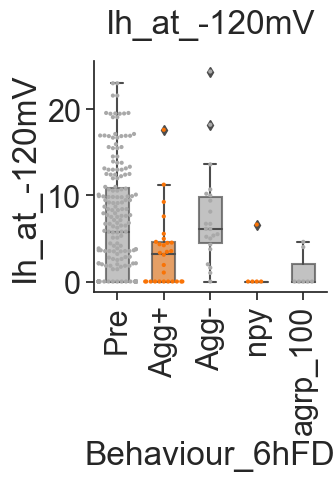

AP_ampl ('Pre', 'Agg+') 0.6356668265471896
AP_ampl ('Pre', 'Agg-') 0.8314572994302365
AP_ampl ('Pre', 'npy') 0.10306564693706645
AP_ampl ('Pre', 'agrp_100') 0.22730854299586456
AP_ampl ('Agg+', 'Agg-') 0.9545567371325373
AP_ampl ('Agg+', 'npy') 0.2645660975485845
AP_ampl ('Agg+', 'agrp_100') 0.23154451949510857
AP_ampl ('Agg-', 'npy') 0.1408065618591934
AP_ampl ('Agg-', 'agrp_100') 0.12511165144592054
AP_ampl ('npy', 'agrp_100') 0.0380952380952381
Behaviour_6hFD
Agg+        88.281429
Agg-        88.562778
Pre         89.226665
agrp_100    97.183333
npy         78.000000
Name: AP_ampl, dtype: float64


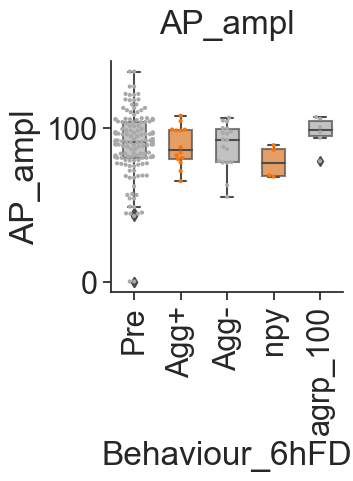

AP_halfwidth ('Pre', 'Agg+') 0.7953775043445768
AP_halfwidth ('Pre', 'Agg-') 0.009756528396627832
AP_halfwidth ('Pre', 'npy') 0.8223712848654395
AP_halfwidth ('Pre', 'agrp_100') 0.5193229651801314
AP_halfwidth ('Agg+', 'Agg-') 0.05977890914371962
AP_halfwidth ('Agg+', 'npy') 0.7905209256143334
AP_halfwidth ('Agg+', 'agrp_100') 0.6205593165585456
AP_halfwidth ('Agg-', 'npy') 0.12406898847488004
AP_halfwidth ('Agg-', 'agrp_100') 0.17061015587584472
AP_halfwidth ('npy', 'agrp_100') 0.7483812122920345
Behaviour_6hFD
Agg+        3.340714
Agg-        2.132222
Pre         3.242297
agrp_100    2.551667
npy         2.700000
Name: AP_halfwidth, dtype: float64


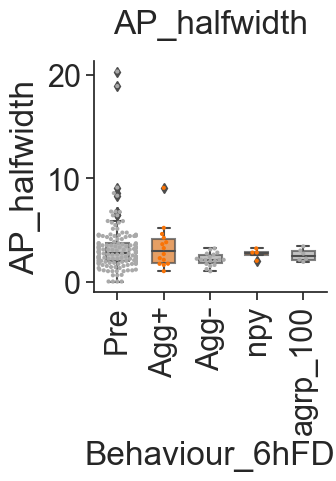

AP_time_to_peak ('Pre', 'Agg+') 0.1410590813350076
AP_time_to_peak ('Pre', 'Agg-') 0.36508995185405846
AP_time_to_peak ('Pre', 'npy') 0.6949646594004566
AP_time_to_peak ('Pre', 'agrp_100') 0.806967557600589
AP_time_to_peak ('Agg+', 'Agg-') 0.30448202263917346
AP_time_to_peak ('Agg+', 'npy') 0.3127780207972083
AP_time_to_peak ('Agg+', 'agrp_100') 0.34232795760103996
AP_time_to_peak ('Agg-', 'npy') 0.2001118789745493
AP_time_to_peak ('Agg-', 'agrp_100') 0.737671052896427
AP_time_to_peak ('npy', 'agrp_100') 0.23808935859160374
Behaviour_6hFD
Agg+        2.152143
Agg-        1.992222
Pre         2.889533
agrp_100    2.025000
npy         2.225000
Name: AP_time_to_peak, dtype: float64


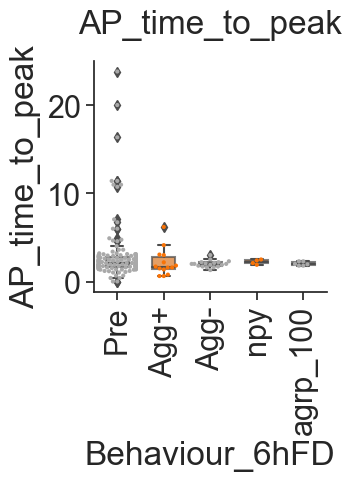

area(mV_ms) ('Pre', 'Agg+') 0.6589289916379197
area(mV_ms) ('Pre', 'Agg-') 0.0026758526710897357
area(mV_ms) ('Pre', 'npy') 0.3604649964896304
area(mV_ms) ('Pre', 'agrp_100') 0.785718093664497
area(mV_ms) ('Agg+', 'Agg-') 0.24657629499295108
area(mV_ms) ('Agg+', 'npy') 1.0
area(mV_ms) ('Agg+', 'agrp_100') 0.649970632034395
area(mV_ms) ('Agg-', 'npy') 0.2015156066227246
area(mV_ms) ('Agg-', 'agrp_100') 0.007399922731730511
area(mV_ms) ('npy', 'agrp_100') 0.11428571428571428
Behaviour_6hFD
Agg+        276.357143
Agg-        212.050000
Pre         315.162867
agrp_100    278.000000
npy         242.450000
Name: area(mV_ms), dtype: float64


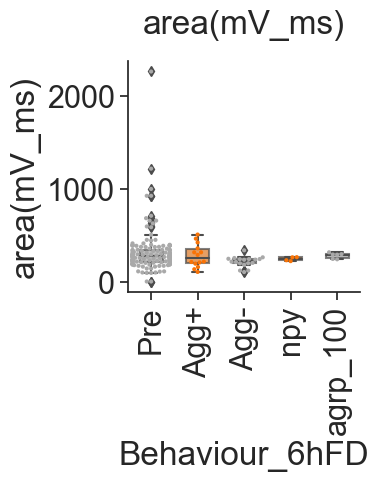

rheobase_at_-60mV_(pA) ('Pre', 'Agg+') 0.12814366123028542
rheobase_at_-60mV_(pA) ('Pre', 'Agg-') 0.08009610215232882
rheobase_at_-60mV_(pA) ('Pre', 'npy') 0.0918113248440891
rheobase_at_-60mV_(pA) ('Pre', 'agrp_100') 0.25870062429928864
rheobase_at_-60mV_(pA) ('Agg+', 'Agg-') 0.9435027026477008
rheobase_at_-60mV_(pA) ('Agg+', 'npy') 0.9798905555562204
rheobase_at_-60mV_(pA) ('Agg+', 'agrp_100') 0.12238492097153196
rheobase_at_-60mV_(pA) ('Agg-', 'npy') 0.3599043918178908
rheobase_at_-60mV_(pA) ('Agg-', 'agrp_100') 0.06128602164583449
rheobase_at_-60mV_(pA) ('npy', 'agrp_100') 0.034926255949542
Behaviour_6hFD
Agg+        23.642857
Agg-        21.904762
Pre         14.701299
agrp_100     7.833333
npy         16.800000
Name: rheobase_at_-60mV_(pA), dtype: float64


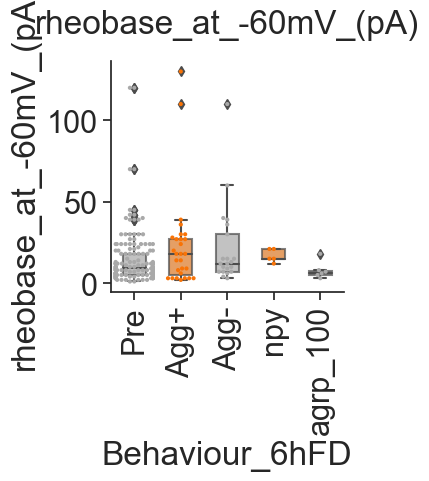

AHP_(mV) ('Pre', 'Agg+') 0.8046015121028867
AHP_(mV) ('Pre', 'Agg-') 0.9296388489981636
AHP_(mV) ('Pre', 'npy') 0.15511988081644407
AHP_(mV) ('Pre', 'agrp_100') 0.8922914668685714
AHP_(mV) ('Agg+', 'Agg-') 0.7756996457252919
AHP_(mV) ('Agg+', 'npy') 0.09957198533497894
AHP_(mV) ('Agg+', 'agrp_100') 0.9015017788988837
AHP_(mV) ('Agg-', 'npy') 0.14774438732340175
AHP_(mV) ('Agg-', 'agrp_100') 0.8939068368941268
AHP_(mV) ('npy', 'agrp_100') 0.2571428571428571
Behaviour_6hFD
Agg+       -51.865714
Agg-       -52.755556
Pre        -52.275011
agrp_100   -52.616667
npy        -58.400000
Name: AHP_(mV), dtype: float64


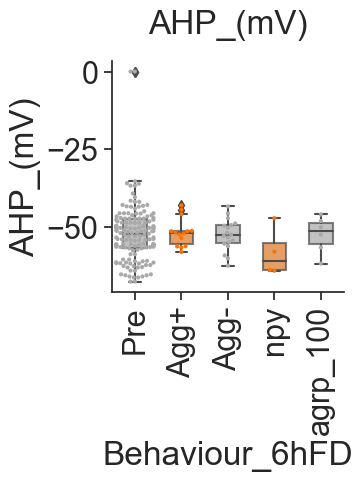

Vm ('Pre', 'Agg+') 0.567069169857365
Vm ('Pre', 'Agg-') 0.6370537134320564
Vm ('Pre', 'npy') 0.12995564489342418
Vm ('Pre', 'agrp_100') 0.8237502362035254
Vm ('Agg+', 'Agg-') 0.524044598549587
Vm ('Agg+', 'npy') 0.4482850324880685
Vm ('Agg+', 'agrp_100') 0.6957458838863012
Vm ('Agg-', 'npy') 0.12924563359345967
Vm ('Agg-', 'agrp_100') 0.7841566396289035
Vm ('npy', 'agrp_100') 0.4318181818181819
Behaviour_6hFD
Agg+       -47.647761
Agg-       -45.997810
Pre        -46.288625
agrp_100   -46.202880
npy        -51.567251
Name: Vm, dtype: float64


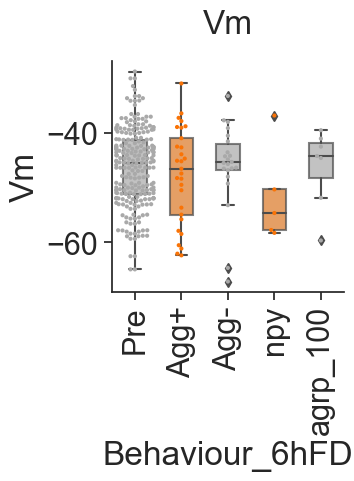

Input_Resistance ('Pre', 'Agg+') 0.005607881939624394
Input_Resistance ('Pre', 'Agg-') 0.4508716060484462
Input_Resistance ('Pre', 'npy') 0.18177784389782048
Input_Resistance ('Pre', 'agrp_100') 0.11530183771413721
Input_Resistance ('Agg+', 'Agg-') 0.014175632041520614
Input_Resistance ('Agg+', 'npy') 0.9032426601948292
Input_Resistance ('Agg+', 'agrp_100') 0.5579767775246413
Input_Resistance ('Agg-', 'npy') 0.09921962095875139
Input_Resistance ('Agg-', 'agrp_100') 0.06975871038839555
Input_Resistance ('npy', 'agrp_100') 0.8762626262626263
Behaviour_6hFD
Agg+        758.993486
Agg-        605.318491
Pre         651.560094
agrp_100    742.687588
npy         771.084327
Name: Input_Resistance, dtype: float64


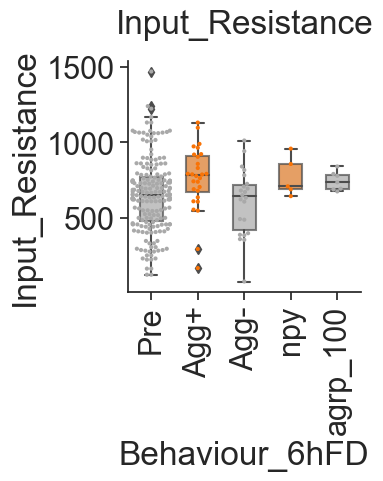

sPSC_frequency ('Pre', 'Agg+') 0.7025731164511213
sPSC_frequency ('Pre', 'Agg-') 0.6210350832400574
sPSC_frequency ('Pre', 'npy') 0.6466611220657192
sPSC_frequency ('Pre', 'agrp_100') 0.5298498820528219
sPSC_frequency ('Agg+', 'Agg-') 0.5471954882695942
sPSC_frequency ('Agg+', 'npy') 0.8319924383594899
sPSC_frequency ('Agg+', 'agrp_100') 0.5382045438616431
sPSC_frequency ('Agg-', 'npy') 0.7393534002229653
sPSC_frequency ('Agg-', 'agrp_100') 0.8061793279184586
sPSC_frequency ('npy', 'agrp_100') 0.42857142857142855
Behaviour_6hFD
Agg+        2.323399
Agg-        1.441626
Pre         1.773319
agrp_100    1.546351
npy         2.458981
Name: sPSC_frequency, dtype: float64


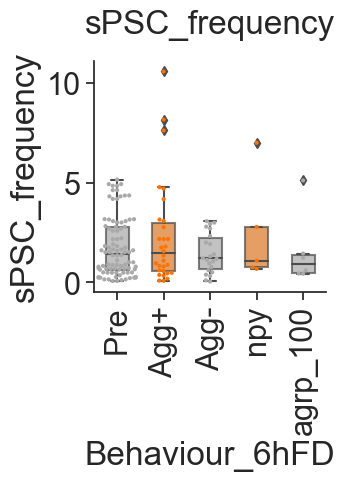

sPSC_Amplitude(pA) ('Pre', 'Agg+') 0.9107189625813171
sPSC_Amplitude(pA) ('Pre', 'Agg-') 0.012630354522276947
sPSC_Amplitude(pA) ('Pre', 'npy') 0.7961182620479392
sPSC_Amplitude(pA) ('Pre', 'agrp_100') 0.2858621604757887
sPSC_Amplitude(pA) ('Agg+', 'Agg-') 0.02680247423736713
sPSC_Amplitude(pA) ('Agg+', 'npy') 0.8016092067325463
sPSC_Amplitude(pA) ('Agg+', 'agrp_100') 0.2028367599738421
sPSC_Amplitude(pA) ('Agg-', 'npy') 0.7308960912748543
sPSC_Amplitude(pA) ('Agg-', 'agrp_100') 0.9552708149569595
sPSC_Amplitude(pA) ('npy', 'agrp_100') 0.7922077922077921
Behaviour_6hFD
Agg+        12.406143
Agg-        11.552273
Pre         12.439461
agrp_100    11.033333
npy         12.080000
Name: sPSC_Amplitude(pA), dtype: float64


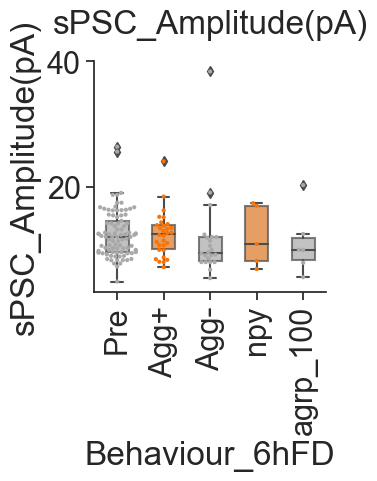

sPSCs_Rise time ('Pre', 'Agg+') 0.1751566179209043
sPSCs_Rise time ('Pre', 'Agg-') 0.2792736588406405
sPSCs_Rise time ('Pre', 'npy') 0.08167115759393427
sPSCs_Rise time ('Pre', 'agrp_100') 0.08073007936112156
sPSCs_Rise time ('Agg+', 'Agg-') 0.08499742358066459
sPSCs_Rise time ('Agg+', 'npy') 0.34168911048871853
sPSCs_Rise time ('Agg+', 'agrp_100') 0.2570344539198529
sPSCs_Rise time ('Agg-', 'npy') 0.1677924771696887
sPSCs_Rise time ('Agg-', 'agrp_100') 0.13615720580576507
sPSCs_Rise time ('npy', 'agrp_100') 0.64351499991621
Behaviour_6hFD
Agg+        1.270000
Agg-        1.300000
Pre         1.190625
agrp_100    1.733333
npy         1.360000
Name: sPSCs_Rise time, dtype: float64


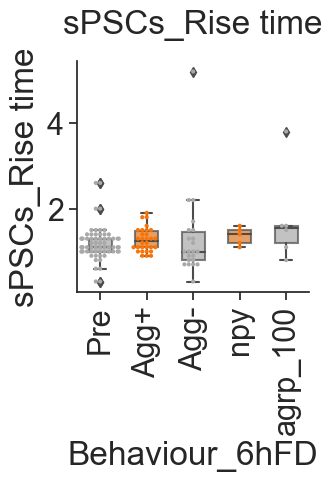

sPSCs (decay) ('Pre', 'Agg+') 0.7994251156426382
sPSCs (decay) ('Pre', 'Agg-') 0.5468056593340226
sPSCs (decay) ('Pre', 'npy') 0.008335979963844437
sPSCs (decay) ('Pre', 'agrp_100') 0.025152920240076697
sPSCs (decay) ('Agg+', 'Agg-') 0.7304515464282084
sPSCs (decay) ('Agg+', 'npy') 0.0249451686833091
sPSCs (decay) ('Agg+', 'agrp_100') 0.057531810378110185
sPSCs (decay) ('Agg-', 'npy') 0.029210889023174567
sPSCs (decay) ('Agg-', 'agrp_100') 0.06610981672463749
sPSCs (decay) ('npy', 'agrp_100') 0.7922077922077921
Behaviour_6hFD
Agg+        10.076323
Agg-         9.619048
Pre          9.392513
agrp_100    14.050000
npy         17.580000
Name: sPSCs (decay), dtype: float64


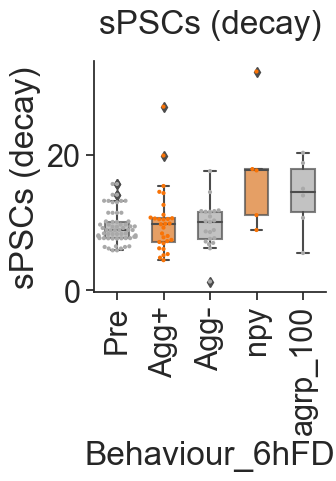

In [9]:
filter_cat = ['Pre', 'Agg+', 'Agg-', 'agrp_100', 'npy']
preprocess_plot(ephys[ephys.Behaviour_6hFD.isin(filter_cat)],'Behaviour_6hFD', 'pan')


Cm(pF) ('yes', 'no') 0.7301587301587302
Gal_positive
no     48.160853
yes    43.144010
Name: Cm(pF), dtype: float64


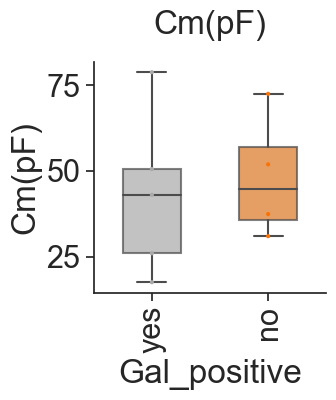

Firing_freq_(Hz)_I0 ('yes', 'no') 1.0
Gal_positive
no     2.565
yes    1.204
Name: Firing_freq_(Hz)_I0, dtype: float64


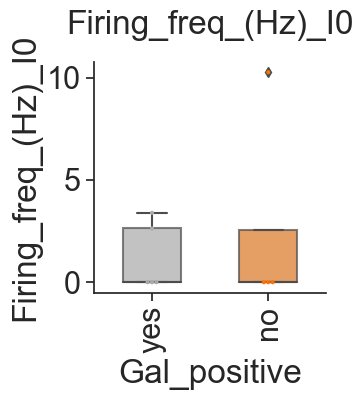

Instant_freq_(Hz) ('yes', 'no') 1.0
Gal_positive
no     2.600
yes    1.348
Name: Instant_freq_(Hz), dtype: float64


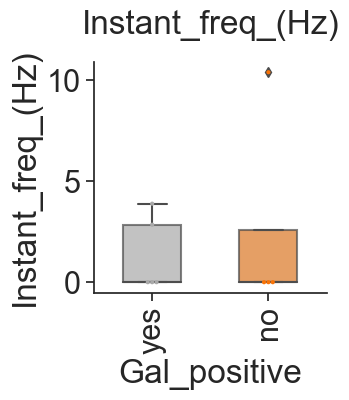

isi_(ms) ('yes', 'no') 0.6666666666666666
Gal_positive
no      97.42
yes    336.00
Name: isi_(ms), dtype: float64


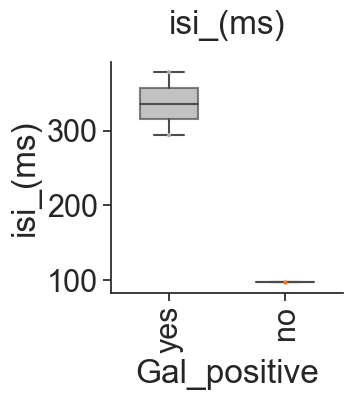

CaT ('yes', 'no') 0.18587673236587587
Gal_positive
no     8.5075
yes    0.0000
Name: CaT, dtype: float64


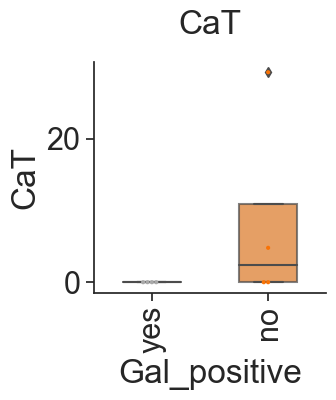

Ih_at_-120mV ('yes', 'no') 0.4427708739877678
Gal_positive
no     3.2875
yes    4.2360
Name: Ih_at_-120mV, dtype: float64


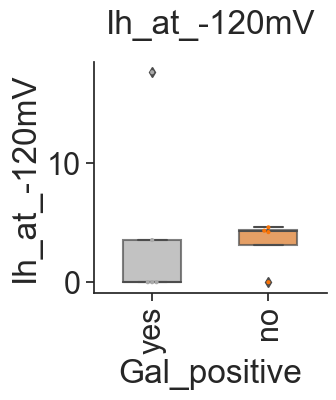

AP_ampl ('yes', 'no') 0.6666666666666666
Gal_positive
no     98.400
yes    72.925
Name: AP_ampl, dtype: float64


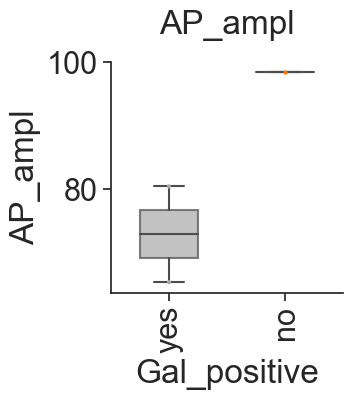

AP_halfwidth ('yes', 'no') 0.6666666666666666
Gal_positive
no     1.71
yes    3.92
Name: AP_halfwidth, dtype: float64


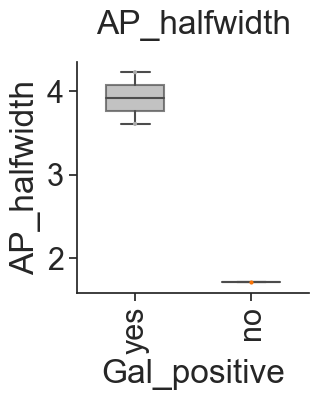

AP_time_to_peak ('yes', 'no') 0.6666666666666666
Gal_positive
no     0.620
yes    1.835
Name: AP_time_to_peak, dtype: float64


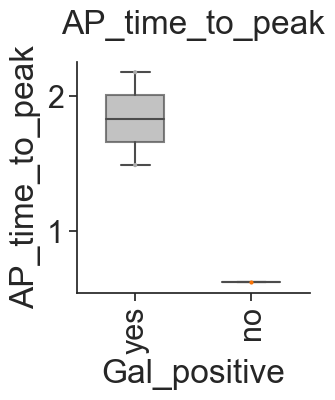

area(mV_ms) ('yes', 'no') 0.6666666666666666
Gal_positive
no     132.0
yes    259.5
Name: area(mV_ms), dtype: float64


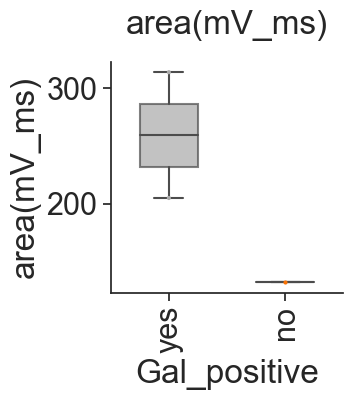

rheobase_at_-60mV_(pA) ('yes', 'no') 0.7086240584439221
Gal_positive
no     39.5
yes    16.8
Name: rheobase_at_-60mV_(pA), dtype: float64


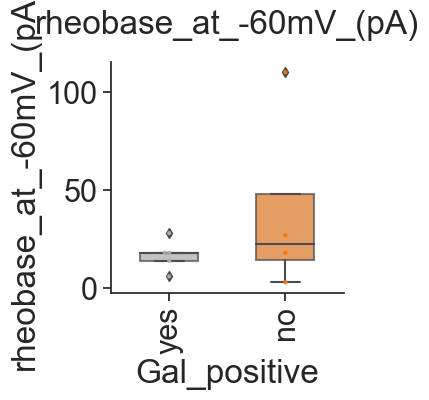

AHP_(mV) ('yes', 'no') 0.6666666666666666
Gal_positive
no    -53.700
yes   -44.575
Name: AHP_(mV), dtype: float64


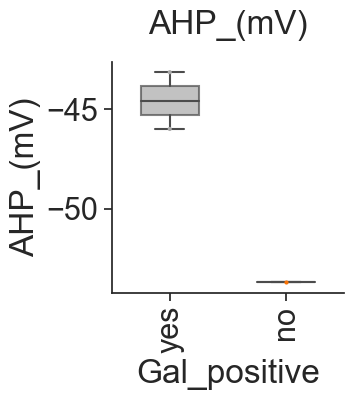

Vm ('yes', 'no') 0.031746031746031744
Gal_positive
no    -54.158175
yes   -41.445957
Name: Vm, dtype: float64


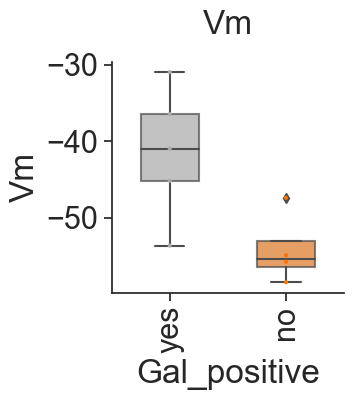

Input_Resistance ('yes', 'no') 0.9047619047619049
Gal_positive
no     672.01175
yes    801.02200
Name: Input_Resistance, dtype: float64


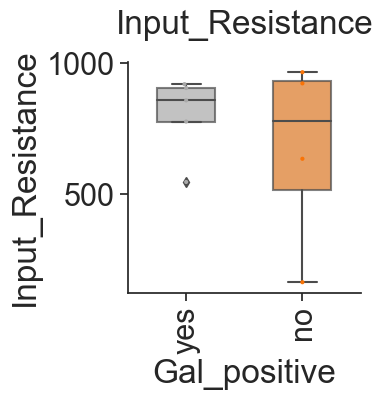

sPSC_frequency ('yes', 'no') 0.7301587301587302
Gal_positive
no     1.634487
yes    3.851209
Name: sPSC_frequency, dtype: float64


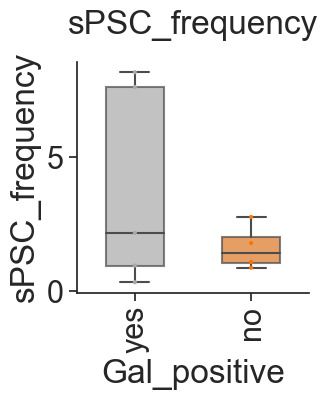

sPSC_Amplitude(pA) ('yes', 'no') 1.0
Gal_positive
no     11.9825
yes    12.4460
Name: sPSC_Amplitude(pA), dtype: float64


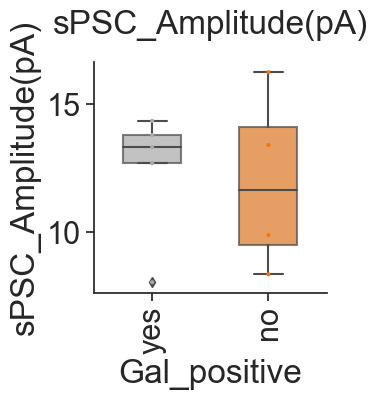

sPSCs_Rise time ('yes', 'no') 0.1987717336168393
Gal_positive
no     1.275
yes    1.520
Name: sPSCs_Rise time, dtype: float64


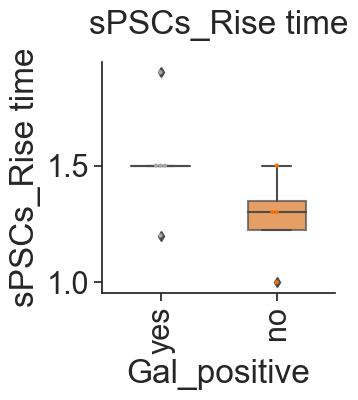

sPSCs (decay) ('yes', 'no') 0.2857142857142857
Gal_positive
no      8.9425
yes    11.1300
Name: sPSCs (decay), dtype: float64


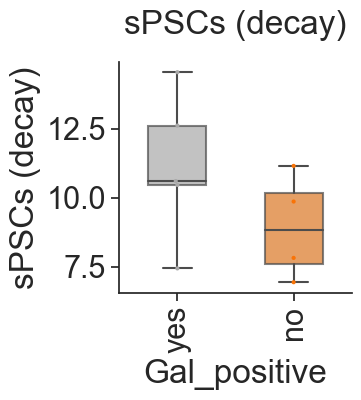

In [42]:
preprocess_plot(ephys[(ephys.Gal_positive.isin(['no', 'yes'])) & (ephys.Behaviour_6hFD.isin(['Agg-', 'Agg+']))], 'Gal_positive', 'gal')


Cm(pF) ('Pre', 'Agg+') 0.4312064746847355


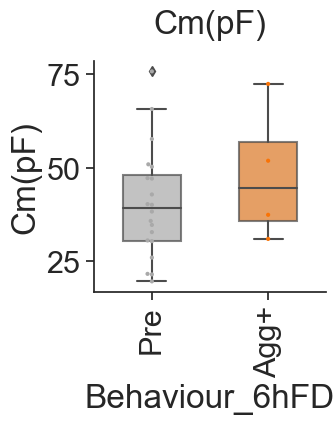

Firing_freq_(Hz)_I0 ('Pre', 'Agg+') 0.4034858988262905


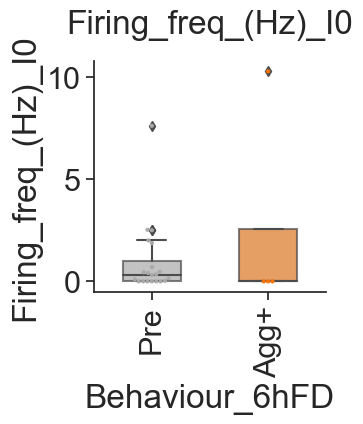

Instant_freq_(Hz) ('Pre', 'Agg+') 0.4034858988262905


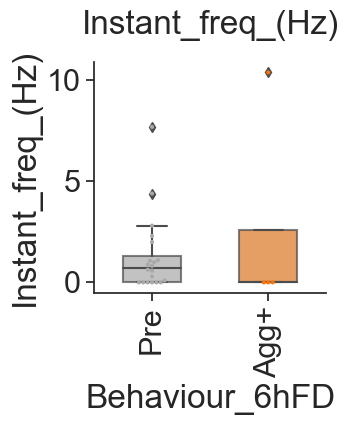

isi_(ms) ('Pre', 'Agg+') 0.13333333333333333


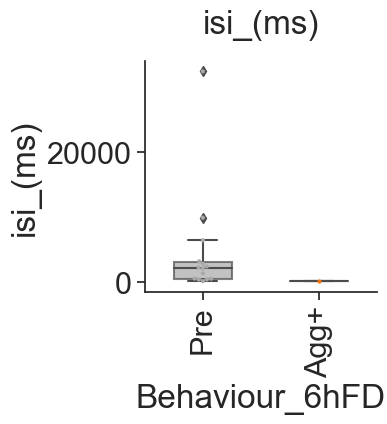

CaT ('Pre', 'Agg+') 0.18249580310381686


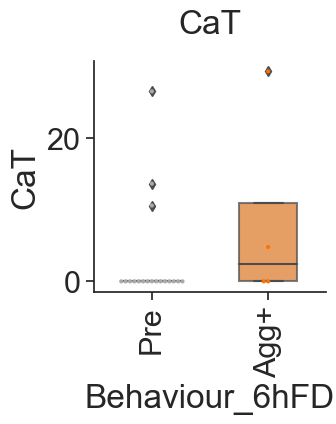

Ih_at_-120mV ('Pre', 'Agg+') 0.9339723158912411


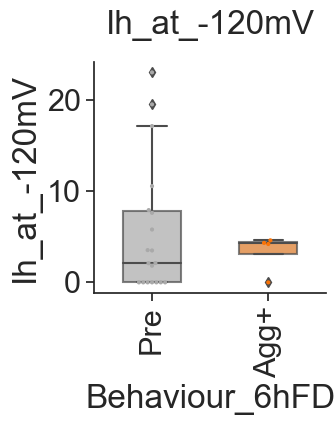

AP_ampl ('Pre', 'Agg+') 0.5333333333333333


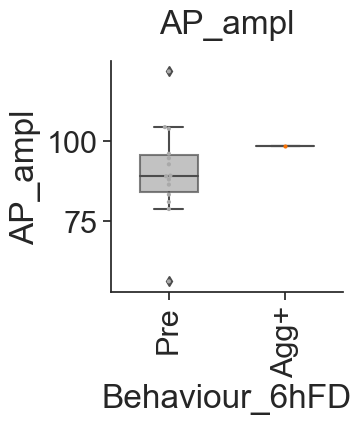

AP_halfwidth ('Pre', 'Agg+') 0.2971897434333751


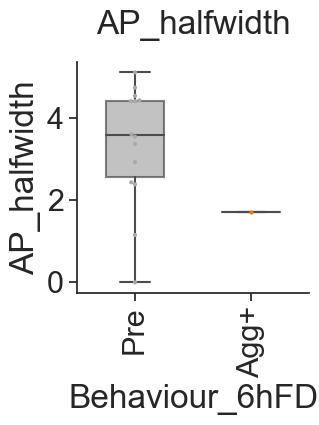

AP_time_to_peak ('Pre', 'Agg+') 0.26666666666666666


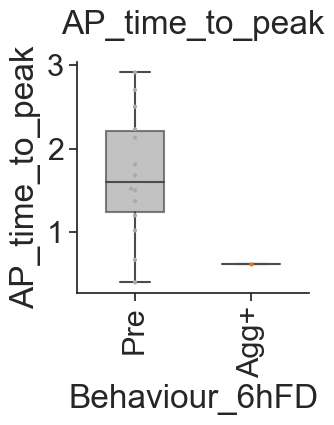

area(mV_ms) ('Pre', 'Agg+') 0.4


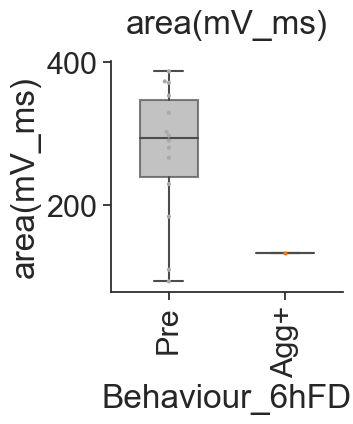

rheobase_at_-60mV_(pA) ('Pre', 'Agg+') 0.5152684554887583


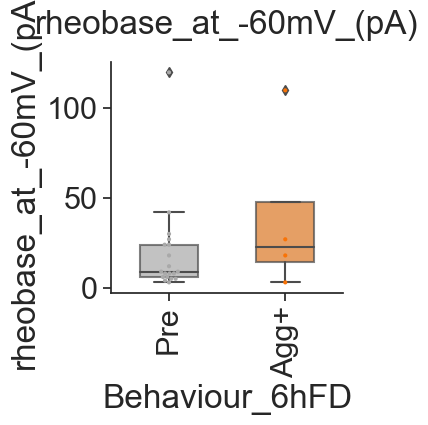

AHP_(mV) ('Pre', 'Agg+') 1.0


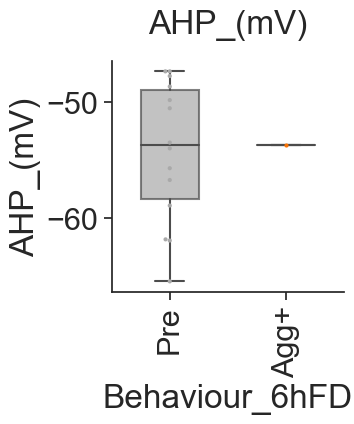

Vm ('Pre', 'Agg+') 0.08112177677395067


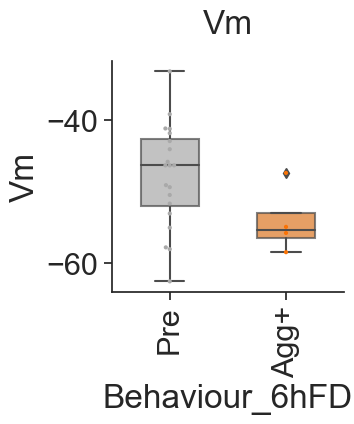

Input_Resistance ('Pre', 'Agg+') 0.9068322981366461


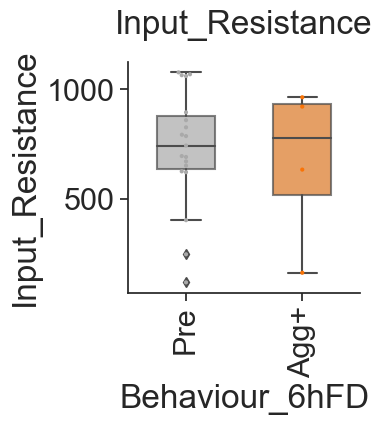

sPSC_frequency ('Pre', 'Agg+') 0.9700734048560136


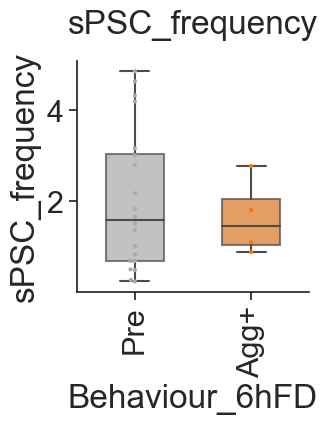

sPSC_Amplitude(pA) ('Pre', 'Agg+') 0.8161651409276747


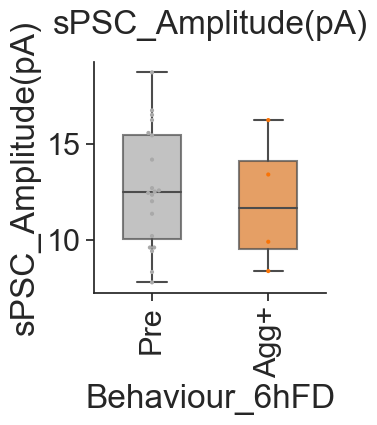

sPSCs_Rise time ('Pre', 'Agg+') 0.7224445223795837


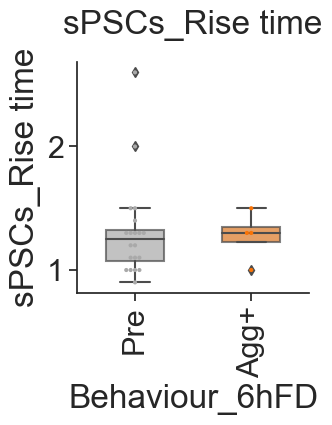

sPSCs (decay) ('Pre', 'Agg+') 1.0


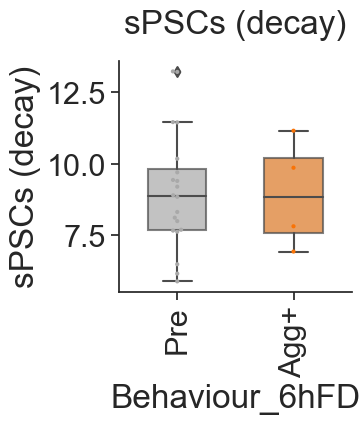

In [43]:
preprocess_plot(no_gal,'gal_minus')

Cm(pF) 0.7323693239926063


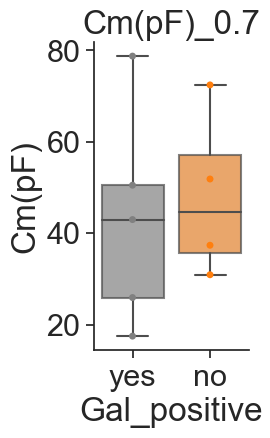

Firing_freq_(Hz)_I0 0.6407646405225094


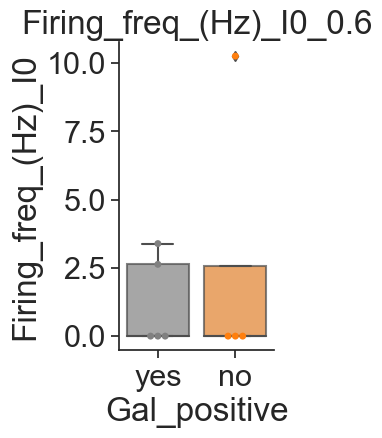

Instant_freq_(Hz) 0.6729139443059836


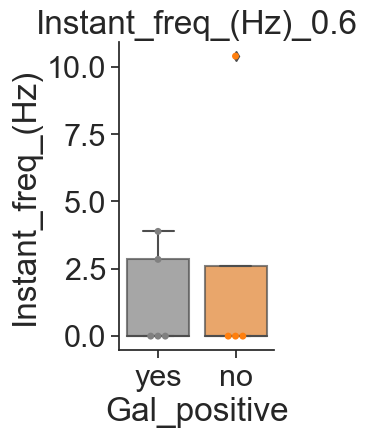

isi_(ms) 0.264690461240659


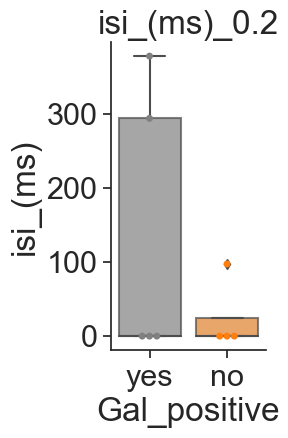

CaT 0.3112911367063223


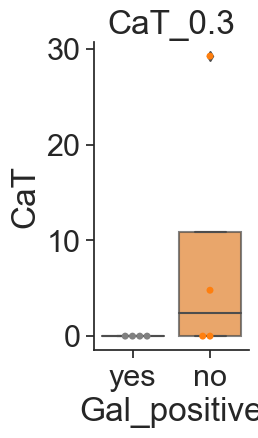

Ih_at_-120mV 0.8027274535869496


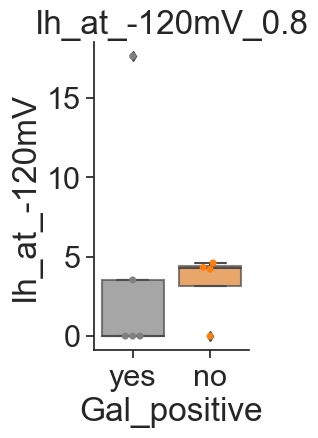

AP_ampl 0.8859255231987084


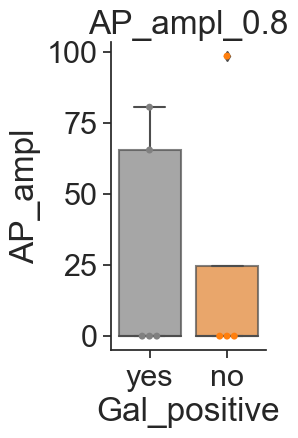

AP_halfwidth 0.32548590700011526


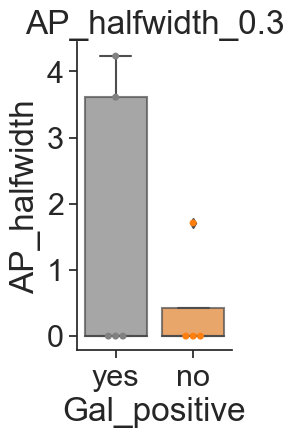

AP_time_to_peak 0.2899382771639767


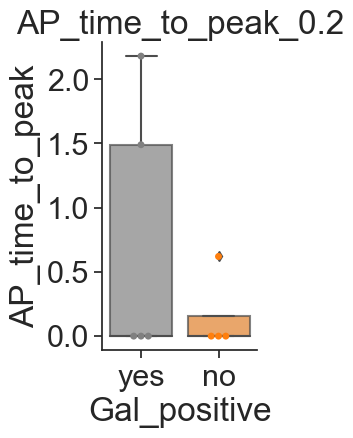

area(mV_ms) 0.37498685458791303


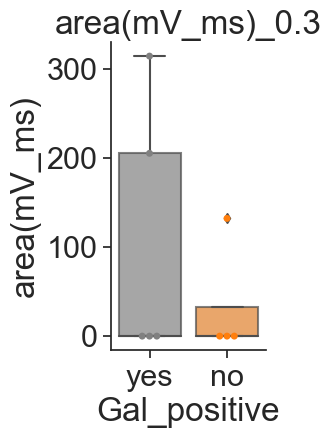

rheobase_at_-60mV_(pA) 0.4161053280322605


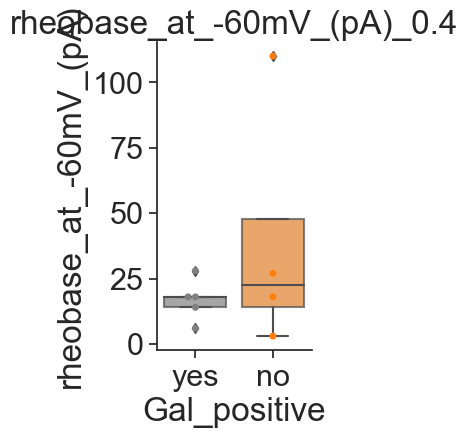

AHP_(mV) 0.80731274924489


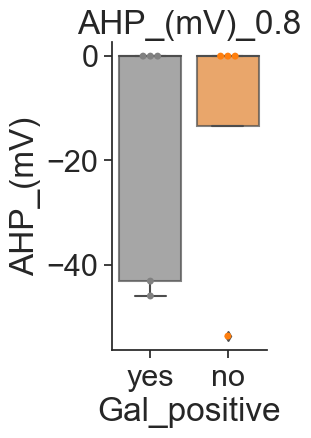

Vm 0.029015379302906888


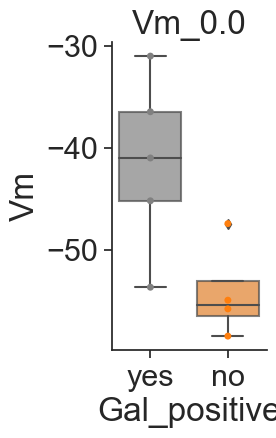

Input_Resistance 0.5478892229399508


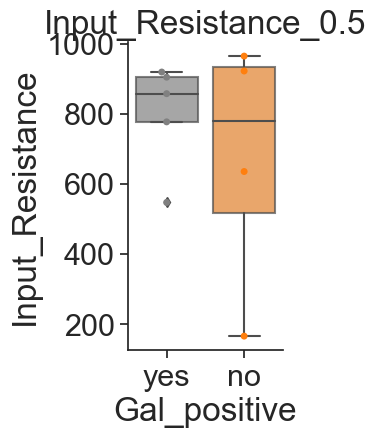

sPSC_frequency 0.2622481192712615


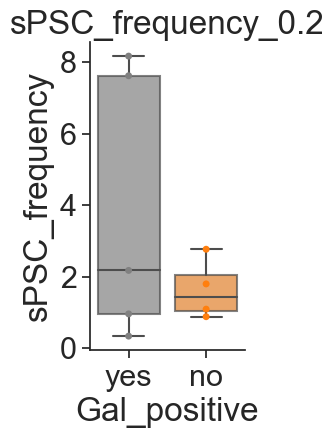

sPSC_Amplitude(pA) 0.8336416545013177


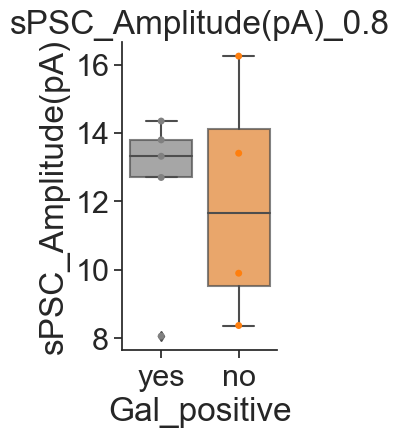

sPSCs_Rise time 0.1506195618276333


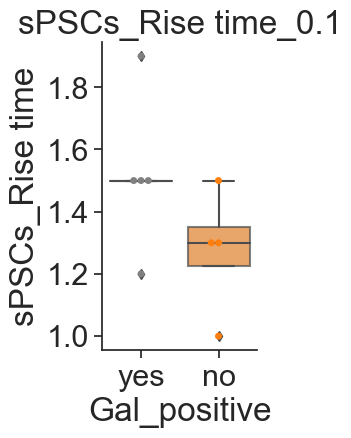

sPSCs (decay) 0.1946103198988765


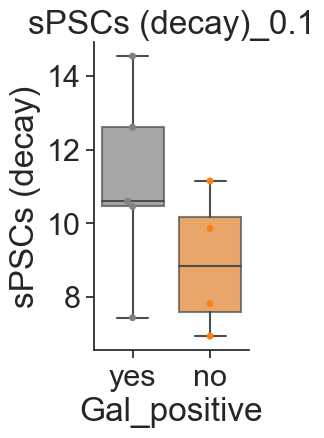

AC-I0 nan
AC_-60 nan


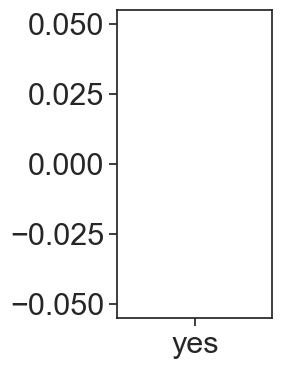

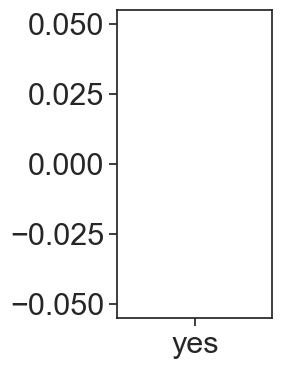

In [64]:
gals = pd.concat([gal,no_gal], axis = 0)
gals = gals[gals.Behaviour_6hFD.isin(['Agg+', 'Agg-'])]

ls = ['Cm(pF)', 'Firing_freq_(Hz)_I0','Instant_freq_(Hz)', 'isi_(ms)',  'CaT',  'Ih_at_-120mV', 'AP_ampl', 'AP_halfwidth', 'AP_time_to_peak','area(mV_ms)', 'rheobase_at_-60mV_(pA)', 'AHP_(mV)', 'Vm',
   'Input_Resistance', 'sPSC_frequency', 'sPSC_Amplitude(pA)','sPSCs_Rise time', 'sPSCs (decay)', 'AC-I0', 'AC_-60']

for column in ls:
    try:
        _, p = stats.ttest_ind(gals[(gals.Gal_positive == 'yes')][column].dropna(),
                                    gals[(gals.Gal_positive == 'no')][column].dropna(),
                                    equal_var = False)
        print(column , p)


        gals[column] = pd.to_numeric(gals[column])
        fig,ax = plt.subplots(figsize = (2,4))
        sns.swarmplot(x='Gal_positive', y =column, data= gals, palette = ['gray', 'Tab:orange'])
        sns.boxplot(x='Gal_positive', y =column, data= gals, palette = ['gray', 'Tab:orange'], boxprops=dict(alpha=0.7))
        sns.despine()
        plt.title(column + '_' + str(p)[:3])
        plt.savefig(f'output_figures/gal_nogal_{column}.png',dpi = 300, bbox_inches = 'tight')
        plt.show()
    except Exception:
        continue

In [10]:
trial = ephys[ephys.Behaviour_6hFD.isin(['Pre', 'Agg-', 'Agg+'])]
trial = trial.rename(columns={'Ih_at_-120mV': 'ih_current', 
                              'Firing_freq_(Hz)_I0': 'firing_freq', 
                              'sPSC_Amplitude(pA)': 'sPSC_Amplitude'})
model = smf.ols('sPSC_Amplitude ~  ih_current  ', data=trial).fit()
#model.summary()
sm.stats.anova_lm(model, typ=2)

,sum_sq,df,F,PR(>F)
ih_current,9.592793,1.0,0.496403,0.482395
Residual,2415.573995,125.0,NaN,NaN


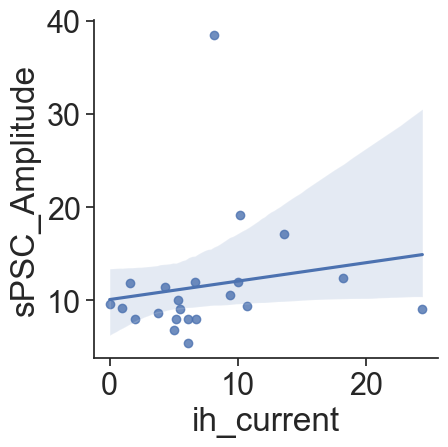

In [12]:
sns.lmplot(x = 'ih_current', y = 'sPSC_Amplitude', data = trial[trial.Behaviour_6hFD == 'Agg-'], palette = ['darkgray', '#F97306', 'blue'])
          


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


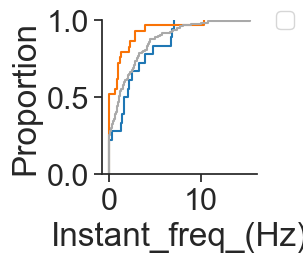

In [13]:
l = 'Instant_freq_(Hz)'
max = ephys[l].max()
cs = ['darkgray', '#F97306', 'Tab:blue']
conds = ['Pre', 'Agg+', 'Agg-']

fig, ax = plt.subplots(figsize=(2, 2))
sns.ecdfplot(data=ephys[ephys.Behaviour_6hFD.isin(conds)], x=l, hue="Behaviour_6hFD", palette = cs, ax = ax)
sns.despine()
plt.legend(loc='center left', bbox_to_anchor=(1.05, 1), fontsize = 16)

plt.savefig(f'output_figures/ECDF_{l}.png',dpi = 300, bbox_inches = 'tight')
plt.show()

    

## silent prop

I_zero          phasic  silent  tonic  All
Behaviour_6hFD                            
Agg+                 6      15      8   29
Agg-                 4       4     14   22
Pre                 40      60    142  242
agrp_100             2       1      4    7
npy                  0       1      4    5
npy_antag            4       3      9   16
All                 56      84    181  321
0.09630509633450614


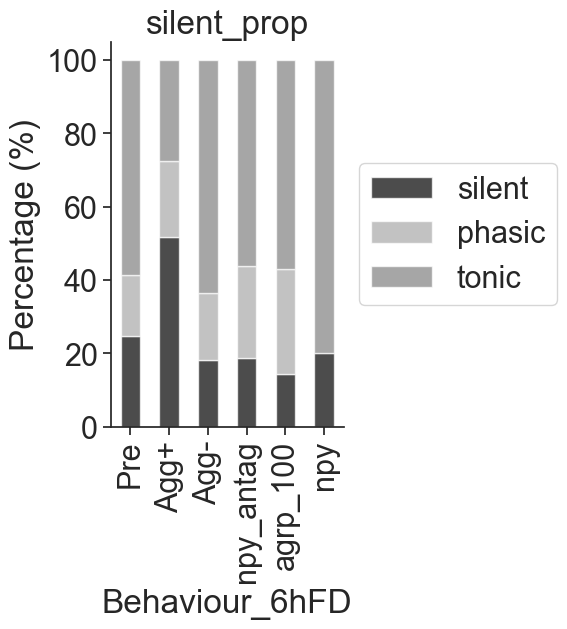

In [17]:
## silent proportion
cols = ['silent', 'phasic', 'tonic']
cat = ['Pre', 'Agg+', 'Agg-', 'npy_antag', 'agrp_100', 'npy']
silent_prop = proportion(ephys[ephys.Behaviour_6hFD.isin(cat)], 'Behaviour_6hFD', 'I_zero', cols)
silent_prop['Behaviour_6hFD'] = pd.Categorical(silent_prop['Behaviour_6hFD'], cat)
silent_prop = silent_prop.sort_values(by = ['Behaviour_6hFD'])
prop_plot(silent_prop, 'Behaviour_6hFD')
plt.xticks(rotation = 90)
plt.title('silent_prop')
plt.savefig('output_figures/silent_prop.png',dpi = 300, bbox_inches = 'tight')

In [69]:
cols = ['silent', 'tonic']
silent_prop = proportion(gals, 'Gal_positive', 'I_zero', cols)
silent_prop['Gal_positive'] = pd.Categorical(silent_prop['Gal_positive'], ['yes', 'no'])
silent_prop = silent_prop.sort_values(by = ['Gal_positive'])
prop_plot(silent_prop, 'Gal_positive')
plt.title('galanin_silent_prop')
plt.savefig('output_figures/galanin_silent_prop.png',dpi = 300, bbox_inches = 'tight')

NameError: name 'gals' is not defined

## adaptive prop

Adaptive        ?  no  yes  All
Behaviour_6hFD                 
Agg+            1  12   16   29
Agg-            0  18    3   21
Pre             2  43   73  118
All             3  73   92  168
0.0011301291465990635


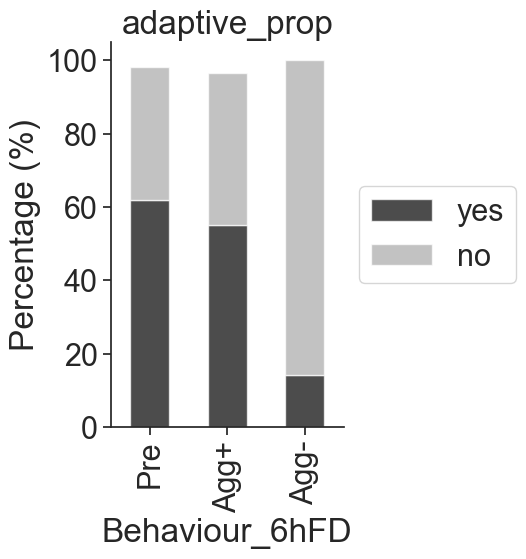

In [19]:
## adaptive proportion
cols = ['yes', 'no']
cat = ['Pre', 'Agg+', 'Agg-']
ad_prop = proportion(ephys[ephys.Behaviour_6hFD.isin(cat)], 'Behaviour_6hFD', 'Adaptive', cols)
ad_prop['Behaviour_6hFD'] = pd.Categorical(ad_prop['Behaviour_6hFD'], cat)
ad_prop = ad_prop.sort_values(by = ['Behaviour_6hFD'])

prop_plot(ad_prop, 'Behaviour_6hFD')
plt.xticks(rotation = 90)
plt.title('adaptive_prop')
plt.savefig('output_figures/adaptive_prop.png',dpi = 300, bbox_inches = 'tight')

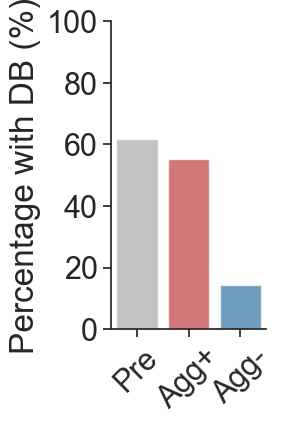

In [33]:
plt.subplots(figsize = (2,4))
sns.barplot(x = 'Behaviour_6hFD', y = 'yes',data = ad_prop, palette= ['darkgray', 'Tab:red', 'Tab:blue'], alpha = 0.7)
plt.xticks(rotation = 45)
plt.ylim([0,100])
plt.ylabel('Percentage with DB (%)')
plt.xlabel('')
sns.despine()
plt.savefig('output_figures/adaptive_prop.pdf',dpi = 300, bbox_inches = 'tight')

Adaptive      no  yes  All
Gal_positive              
no             2    2    4
yes            3    2    5
All            5    4    9
1.0


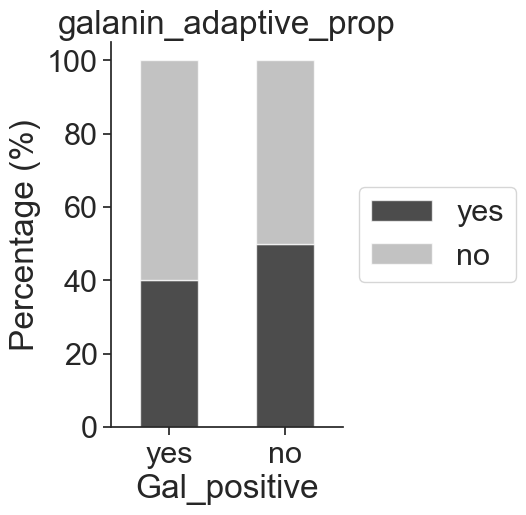

In [71]:
cols = ['yes', 'no']
ad_prop = proportion(gals, 'Gal_positive', 'Adaptive', cols)
ad_prop['Gal_positive'] = pd.Categorical(ad_prop['Gal_positive'], ['yes', 'no'])
ad_prop = ad_prop.sort_values(by = ['Gal_positive'])
prop_plot(ad_prop, 'Gal_positive')
plt.title('galanin_adaptive_prop')
plt.savefig('output_figures/galanin_adaptive_prop.png',dpi = 300, bbox_inches = 'tight')

## calcium T prop

cat_categ        no  no   yes  yes   All
Behaviour_6hFD                          
Agg+             20    0    8     0   28
Agg-              9    1   11     1   22
Pre             111    0   85     0  196
ZD7288            8    0    4     0   12
agrp_100          6    0    2     0    8
npy_antag        14    0    1     0   15
All             168    1  111     1  281
0.0018375158529714865


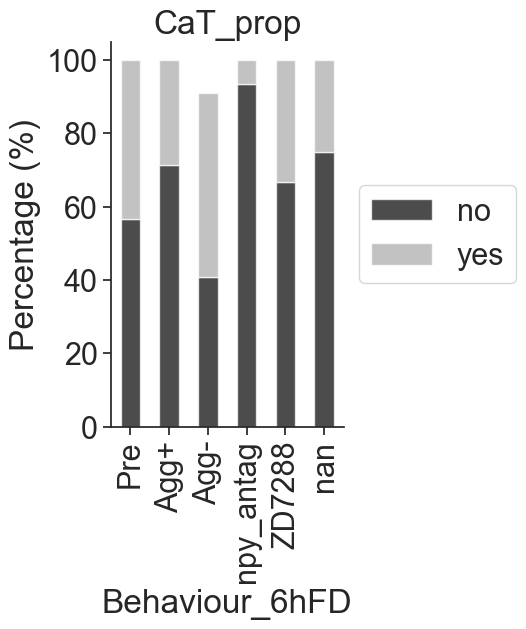

In [20]:
## calcium T proportion
cols = ['no', 'yes']
ca_prop = proportion(ephys, 'Behaviour_6hFD', 'cat_categ', cols)
ca_prop['Behaviour_6hFD'] = pd.Categorical(ca_prop['Behaviour_6hFD'],cat)
ca_prop = ca_prop.sort_values(by = ['Behaviour_6hFD'])
prop_plot(ca_prop, 'Behaviour_6hFD')
plt.xticks(rotation = 90)

plt.title('CaT_prop')
plt.savefig('output_figures/CaT_prop.png',dpi = 300, bbox_inches = 'tight')

cat_categ     no  yes  All
Gal_positive              
no             2    2    4
yes            4    1    5
All            6    3    9
0.8125242693153686


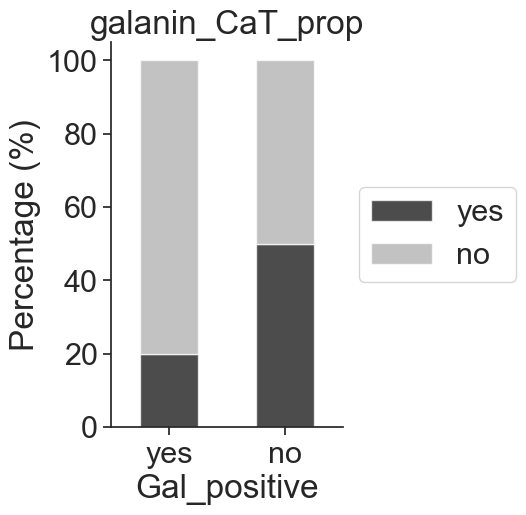

In [73]:
cols = ['yes', 'no']
ca_prop = proportion(gals, 'Gal_positive', 'cat_categ', cols)
ca_prop['Gal_positive'] = pd.Categorical(ca_prop['Gal_positive'], ['yes', 'no'])
ca_prop = ca_prop.sort_values(by = ['Gal_positive'])
prop_plot(ca_prop, 'Gal_positive')

plt.title('galanin_CaT_prop')
plt.savefig('output_figures/galanin_CaT_prop.png',dpi = 300, bbox_inches = 'tight')

IH              no  yes  All
Behaviour_6hFD              
Pre             19   33   52
Agg+             5   10   15
Agg-             0    4    4
npy_antag        0    3    3
npy_10           0    4    4
agrp_100         1    3    4
ZD7288           8    0    8
0.002261477683206594


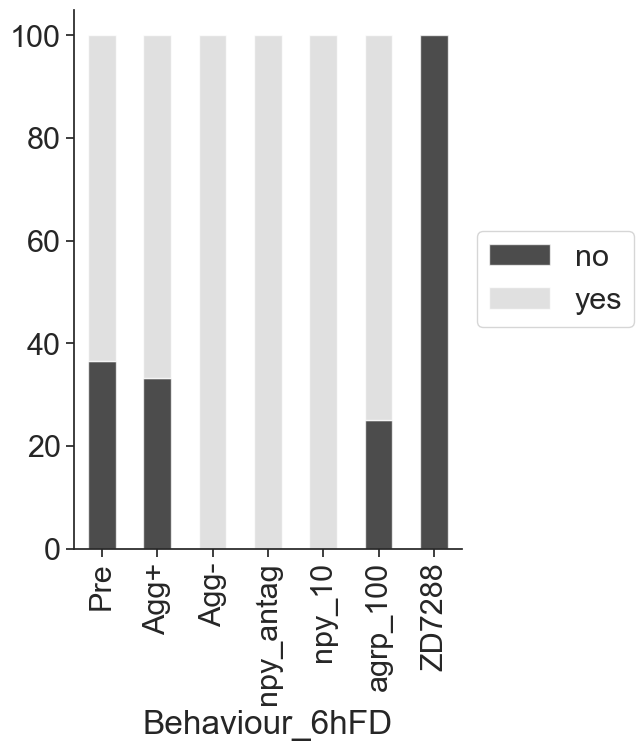

In [21]:
## prop of silent cells with/ without DB
DB_df = ephys[ephys.I_zero == 'silent']

DB_df.loc[(DB_df['Ih_at_-120mV'] == 0), 'IH']  = 'no'
DB_df.loc[(DB_df['Ih_at_-120mV'] >0 ), 'IH']  = 'yes'
DB_prop = pd.crosstab(DB_df['Behaviour_6hFD'], DB_df['IH'], margins = True).reset_index()
cols = ['Behaviour_6hFD', 'no', 'yes','All']
DB_prop = DB_prop[cols]
DB_prop['Behaviour_6hFD'] = pd.Categorical(DB_prop['Behaviour_6hFD'], cat)
DB_prop = DB_prop.sort_values(by = ['Behaviour_6hFD']).dropna()

plot_df = DB_prop.copy()

## chi square test
DB_prop.index = DB_prop.Behaviour_6hFD
DB_prop.drop(columns = ['Behaviour_6hFD'], inplace = True)
c, p, dof, expected = stats.chi2_contingency(DB_prop.iloc[:,:-1]) 
print(DB_prop)
print(p)

## plotting
plot_df.iloc[:, 1:5] = plot_df.iloc[:, 1:5].div(plot_df.All, axis = 0) *100
plot_df = plot_df.iloc[:, :-1]
plot_df.plot(
          x = 'Behaviour_6hFD', 
          kind = 'bar', 
          stacked = True,  
          mark_right = False,
          color = ['black','lightgray'],
          figsize = (5,7), alpha = 0.7)

ax = plt.gca()
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
# plt.ylabel('percentage of neurons with Calium T')

## IH prop

IH              no  yes  All
Behaviour_6hFD              
Agg+            11   17   28
Agg-             1   21   22
Pre             54  142  196
ZD7288          12    0   12
agrp_100         1    7    8
npy_10           0    5    5
npy_100          2    1    3
npy_antag        3   12   15
All             84  205  289
3.181133519867501e-07


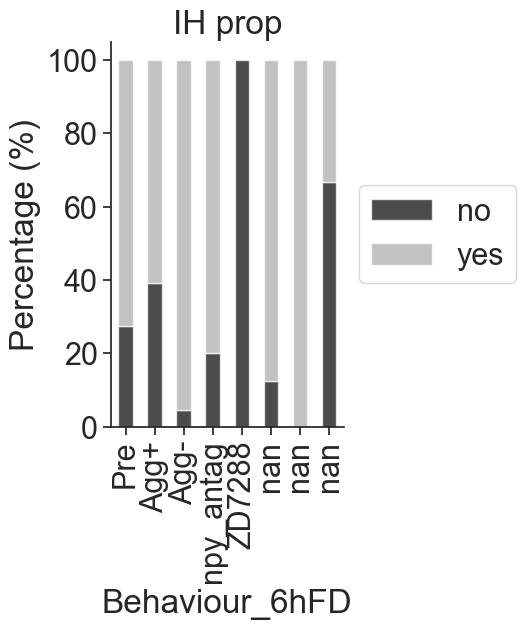

In [31]:
ephys.loc[(ephys['Ih_at_-120mV'] == 0), 'IH']  = 'no'
ephys.loc[(ephys['Ih_at_-120mV'] >0 ), 'IH']  = 'yes'
cols = ['no', 'yes']

ca_prop = proportion(ephys, 'Behaviour_6hFD', 'IH', cols)
ca_prop['Behaviour_6hFD'] = pd.Categorical(ca_prop['Behaviour_6hFD'], cat)
ca_prop = ca_prop.sort_values(by = ['Behaviour_6hFD'])
prop_plot(ca_prop, 'Behaviour_6hFD')

plt.title('IH prop')
plt.xticks(rotation = 90)
plt.savefig('output_figures/IH_prop.png',dpi = 300, bbox_inches = 'tight')

IH                   no  yes  All
I_zero_reclassified              
phasic                9   38   47
silent               36   58   94
tonic                35  104  139
tonic                 2    5    7
All                  82  205  287
0.06621211376592874


Text(0.5, 0, '')

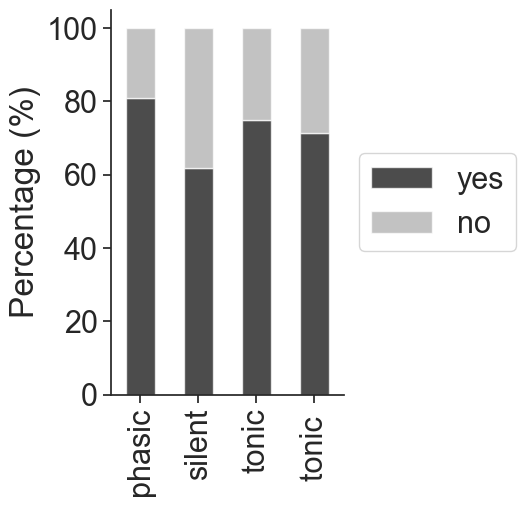

In [23]:
cols = ['yes', 'no']
ih_prop =  proportion(ephys, 'I_zero_reclassified', 'IH', cols)
# ca_prop = ca_prop.sort_values(by = ['Behaviour_6hFD'])
prop_plot(ih_prop, 'I_zero_reclassified')
plt.xticks(rotation = 90)
plt.xlabel('')

# ramp analysis

In [89]:
df = pd.read_csv('ramps_all.csv')
ephys = pd.read_csv('sampled_ephys_data.csv')
ephys.rename(columns = {'Instant_freq_(Hz)_1/ISI':'Instant_freq_(Hz)', 
                        'experiment_day':'filename'}, inplace =True)

df.rename(columns = {'I_Injected(pA)': 'Injected'}, inplace = True)
df = pd.merge(df, ephys, on = 'filename')

df['Injected'] = pd.Categorical(df['Injected'], df['Injected'].unique()[:-2]).as_ordered()

start = df['Ramp_start'][0]
num_spike = df.groupby(by = ['filename', 'Injected']).size().reset_index(name ='num_spike')
df = df.groupby(['filename', 'Injected'], dropna = False).first().reset_index().drop_duplicates()

df.loc[df['Event start '] == 0,'Event start '] = 2080
df['latency'] = df['Event start ']- start
df['num_spike'] = num_spike.num_spike
df =  pd.merge(df, ephys, on = ['filename', 'Behaviour_6hFD'])



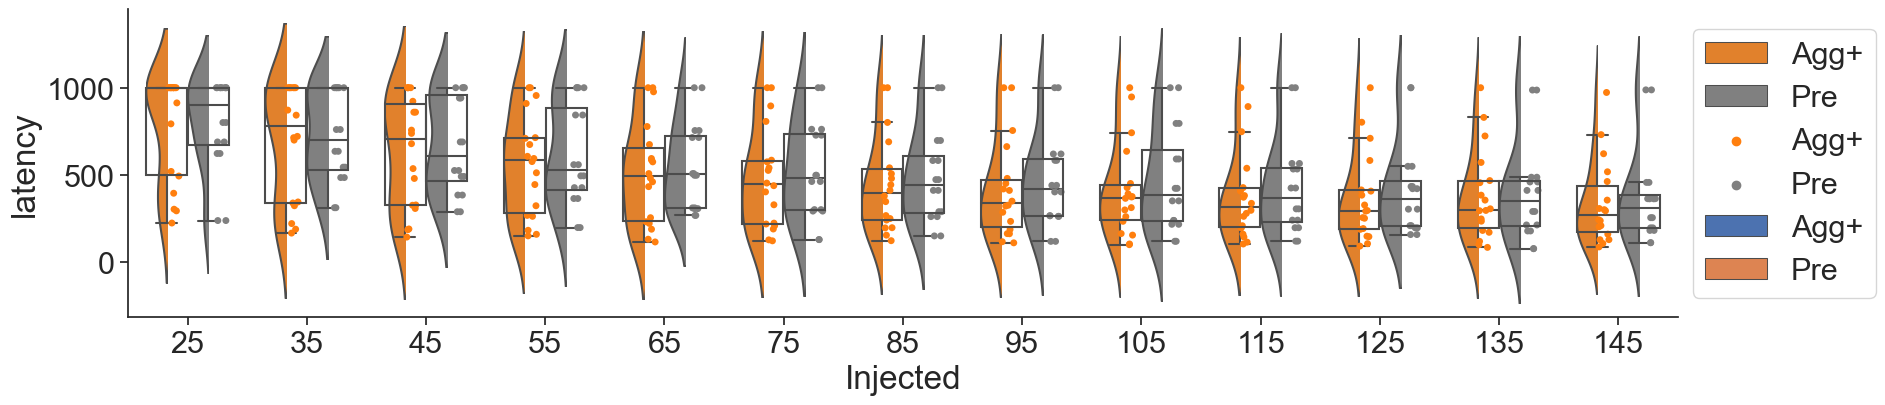

In [90]:
prop = 'latency'

fig = plt.subplots(figsize = [20,4])

palette = ['Tab:orange', 'gray']
ax = sns.violinplot(x ='Injected', y = prop, hue = 'Behaviour_6hFD', 
                    dodge = True, data = df,
                    palette=palette,width = 0.7,
                    scale="width", inner=None)

# ax = sns.lmplot(x ='Injected', y = prop, hue = 'Behaviour_6hFD', data = df)
xlim = ax.get_xlim()
ylim = ax.get_ylim()
for violin in ax.collections:
    bbox = violin.get_paths()[0].get_extents()
    x0, y0, width, height = bbox.bounds
    violin.set_clip_path(plt.Rectangle((x0, y0), width / 2, height, transform=ax.transData))

old_len_collections = len(ax.collections)
sns.stripplot(x  = 'Injected', y = prop, hue = 'Behaviour_6hFD',
               dodge = True, data = df, palette=palette, ax=ax)

sns.boxplot(x  = 'Injected', y = prop, hue = 'Behaviour_6hFD',
                data = df, saturation=1, showfliers=False,
            width=0.7, boxprops={'zorder': 3, 'facecolor': 'none'}, ax=ax)


for dots in ax.collections[old_len_collections:]:
    dots.set_offsets(dots.get_offsets() + np.array([.08, 0]))
    
ax.set_xlim(xlim)
ax.set_ylim(ylim)

sns.despine()
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))

In [91]:
model = smf.ols('latency ~ C(Injected) * C(Behaviour_6hFD)', data=df).fit()
#model.summary()
sm.stats.anova_lm(model, typ=2)

,sum_sq,df,F,PR(>F)
C(Injected),7.381683e+06,12.0,8.054835,1.237526e-13
C(Behaviour_6hFD),1.470714e+05,1.0,1.925798,1.659617e-01
C(Injected):C(Behaviour_6hFD),1.909296e+04,12.0,0.020834,1.000000e+00
Residual,3.176953e+07,416.0,NaN,NaN


In [36]:
df['combination'] = df.Injected.astype(str) + " / " + df.Behaviour_6hFD
m_comp = pairwise_tukeyhsd(endog=df['latency'], groups=df['combination'], alpha=0.05)
m_comp._results_table

group1,group2,meandiff,p-adj,lower,upper,reject
105 / Agg+,105 / no_FD,53.6741,1.0,-402.1284,509.4766,False
105 / Agg+,115 / Agg+,-24.5592,1.0,-389.2012,340.0828,False
105 / Agg+,115 / no_FD,10.2366,1.0,-445.5659,466.0391,False
105 / Agg+,125 / Agg+,-40.0064,1.0,-404.6483,324.6356,False
105 / Agg+,125 / no_FD,-4.3258,1.0,-460.1283,451.4766,False
105 / Agg+,135 / Agg+,-25.7058,1.0,-390.3478,338.9361,False
105 / Agg+,135 / no_FD,-25.2135,1.0,-481.016,430.5889,False
105 / Agg+,145 / Agg+,-68.4944,1.0,-433.1364,296.1476,False
105 / Agg+,145 / no_FD,-48.6384,1.0,-504.4409,407.1641,False
105 / Agg+,25 / Agg+,359.0997,0.0598,-5.5423,723.7417,False


# estrous cycle influence

I_zero         phasic  silent  tonic  All
estrous_stage                            
?                   2       2      4    8
D                  19      18     60   97
E                   7      14     22   43
M                   6       8     17   31
P                   2      10     19   31
no VS               2       4     18   24
not taken           2       4      2    8
All                40      60    142  242
0.32195013681923096
I_zero          phasic  silent  tonic  All
estrous_stage                             
D                    2       5      3   10
E                    3       1      0    4
M                    0       6      3    9
P                    1       3      2    6
to be stained        2       4     12   18
All                  8      19     20   47
0.019141675228478677


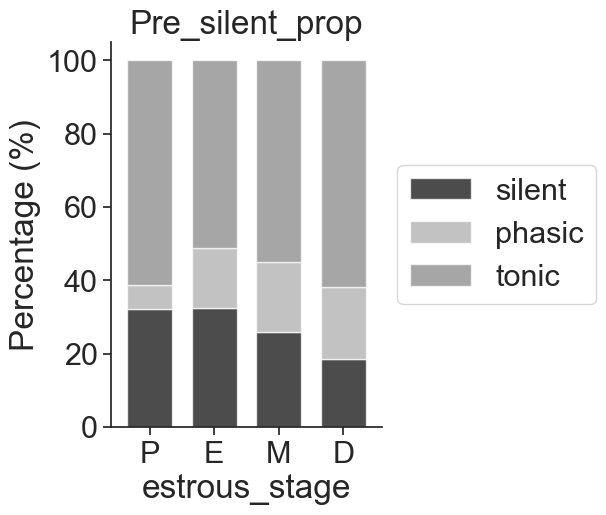

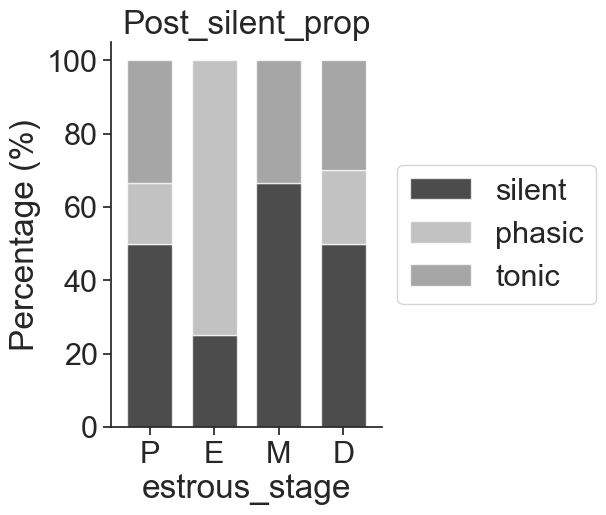

In [42]:
# silent proportion
ephys = pd.read_csv('sampled_ephys_data.csv')

ephys = ephys[ephys.I_zero.isin(['silent', 'phasic', 'tonic'])]
ephys.loc[(ephys['estrous_stage'] == 'P to E'), 'estrous_stage']  = 'P'
ephys.loc[(ephys['estrous_stage'] == 'D to P'), 'estrous_stage']  = 'D'
cols = ['silent', 'phasic', 'tonic']
ephys.loc[ephys.Behaviour_6hFD.isin(['Agg+', 'Agg-']),'Behaviour_6hFD'] = 'Post'

for state in ['Pre', 'Post']:
    state_df = ephys[ephys.Behaviour_6hFD == state]
    silent_prop = proportion(state_df, 'estrous_stage', 'I_zero', cols)
    silent_prop['estrous_stage'] = pd.Categorical(silent_prop['estrous_stage'], ['P', 'E', 'M', 'D'])
    silent_prop = silent_prop.sort_values(by = ['estrous_stage'])
    silent_prop = silent_prop[silent_prop.estrous_stage.isin(['P', 'E', 'M', 'D'])]
    


    silent_prop.plot(x = 'estrous_stage', 
            kind = 'bar', 
            stacked = True,  
            mark_right = False,
            color = ['black', 'darkgray','gray'],
            figsize = (3.5,5), alpha = 0.7, width = 0.7)
 
        
    plt.xticks(rotation = 0)
    ax = plt.gca()
    plt.ylabel('Percentage (%)')
    plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
    
    plt.title(f'{state}_silent_prop')
    plt.savefig(f'output_figures/{state}_silent_prop.png',dpi = 300, bbox_inches = 'tight')

0.9561210031081586 0.04387899689184138


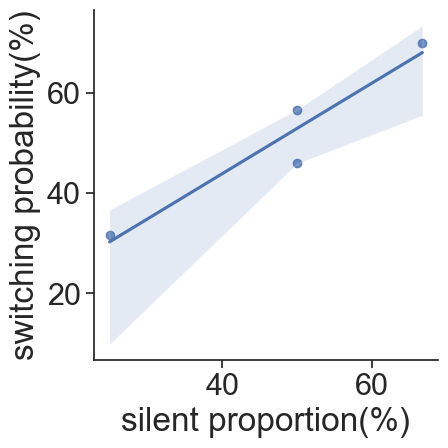

In [43]:
import scipy as sp
estrous_df = pd.read_csv('../NPS_behaviour_analysis/generated_datasets/estrous_data.csv')
estrous_df.rename(columns = {'Unnamed: 0':'estrous_stage', '0':'switching probability'}, inplace = True)
corr = pd.merge(silent_prop, estrous_df, on = 'estrous_stage')

r, p = sp.stats.pearsonr(corr['switching probability'], corr['silent'])
print(r, p)
sns.lmplot(x = 'silent', y = 'switching probability', data = corr)
plt.xlabel('silent proportion(%)')
plt.ylabel('switching probability(%)')
plt.savefig('output_figures/silent_switching_corr.png', dpi = 300, bbox_inches = 'tight')

In [43]:
print(stats.f_oneway(state_df[column][state_df['estrous_stage'] == 'P'].dropna(),
                                    state_df[column][state_df['estrous_stage'] == 'M'].dropna()))
            

F_onewayResult(statistic=7.484263471544963, pvalue=0.008075423471291919)


F_onewayResult(statistic=0.30620289662472505, pvalue=0.8208472597269492)


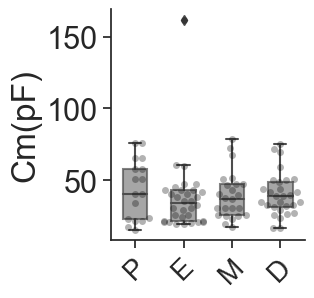

F_onewayResult(statistic=0.1963005199361922, pvalue=0.898841861798042)


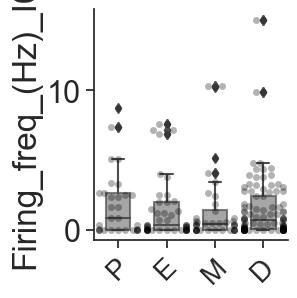

F_onewayResult(statistic=0.11478834930675007, pvalue=0.95137744675152)


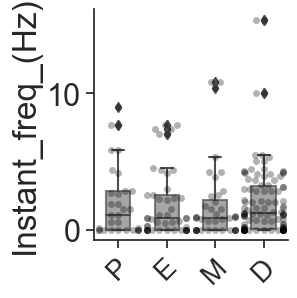

F_onewayResult(statistic=1.5252383390498137, pvalue=0.2089086103593117)


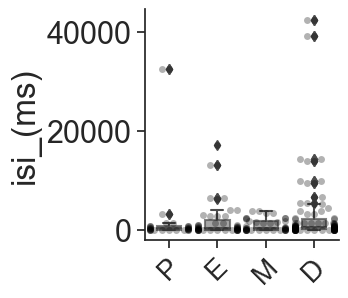

F_onewayResult(statistic=0.7715346736537021, pvalue=0.5112394746660947)


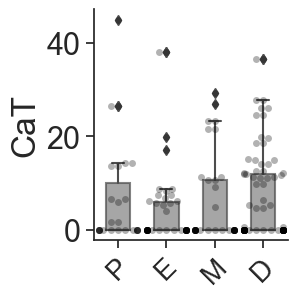

F_onewayResult(statistic=4.131287522693531, pvalue=0.007231270344155889)


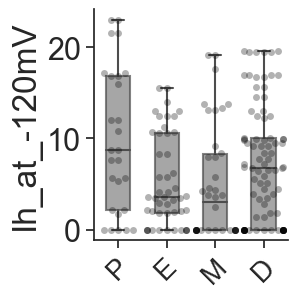

F_onewayResult(statistic=0.825715920276025, pvalue=0.4810651975602024)


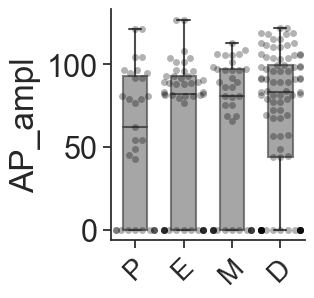

F_onewayResult(statistic=0.9785153747407629, pvalue=0.4038807160834348)


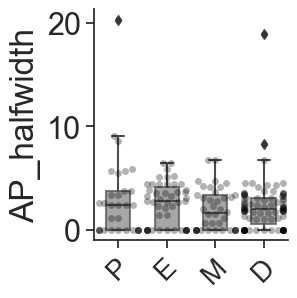

F_onewayResult(statistic=0.8811500645153144, pvalue=0.45176212070042965)


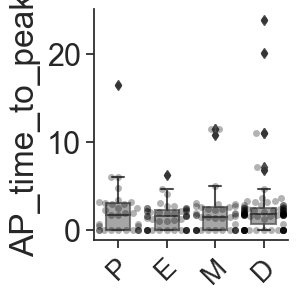

F_onewayResult(statistic=0.3450428487634859, pvalue=0.7927753266383033)


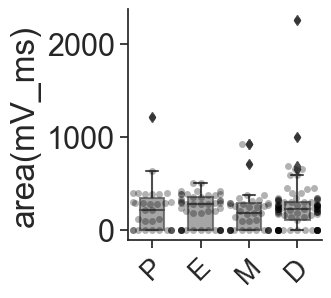

F_onewayResult(statistic=5.600811856023621, pvalue=0.0011245654086509398)


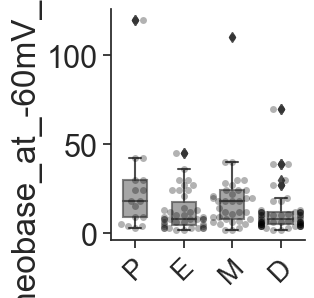

F_onewayResult(statistic=0.48976040719122765, pvalue=0.6897753520691796)


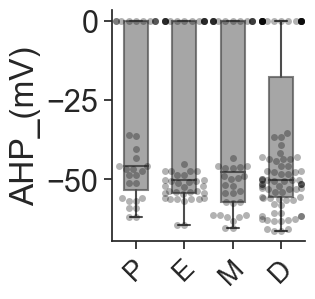

F_onewayResult(statistic=0.8311664572571977, pvalue=0.47802624762512624)


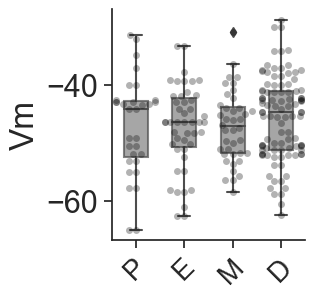

F_onewayResult(statistic=8.100149714772941, pvalue=4.130331533857047e-05)


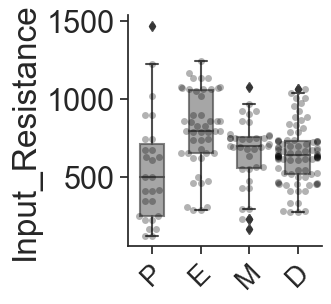

F_onewayResult(statistic=1.9560827789891546, pvalue=0.1250612110267247)


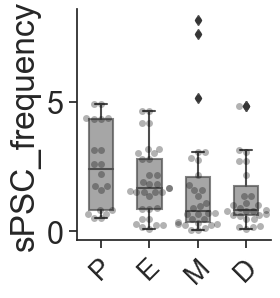

F_onewayResult(statistic=1.8053466226615527, pvalue=0.15065340007658823)


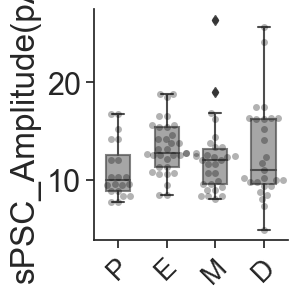

F_onewayResult(statistic=2.3320599551303336, pvalue=0.08036396398049227)


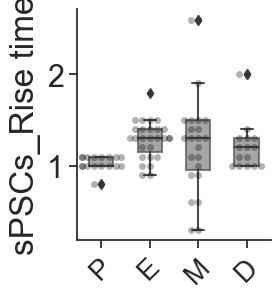

F_onewayResult(statistic=1.8029329141420027, pvalue=0.15354339477354018)


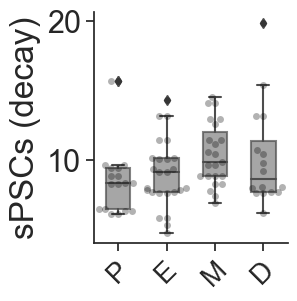

F_onewayResult(statistic=1.1688182850767281, pvalue=0.33363171282257625)
F_onewayResult(statistic=3.7208446444911565, pvalue=0.018871194740943308)


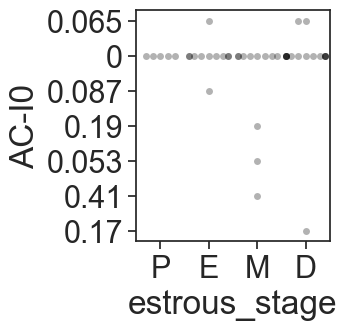

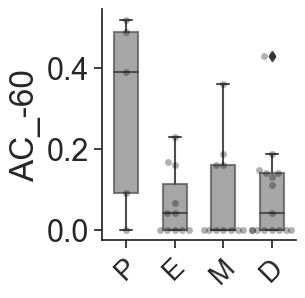

In [10]:
# IH current
ls = ['Cm(pF)', 'Firing_freq_(Hz)_I0','Instant_freq_(Hz)', 'isi_(ms)',  'CaT',  'Ih_at_-120mV', 'AP_ampl', 'AP_halfwidth', 'AP_time_to_peak','area(mV_ms)', 'rheobase_at_-60mV_(pA)', 'AHP_(mV)', 'Vm',
       'Input_Resistance', 'sPSC_frequency', 'sPSC_Amplitude(pA)','sPSCs_Rise time', 'sPSCs (decay)', 'AC-I0', 'AC_-60']

# ls = ['Ih_at_-120mV']

for state in ['Pre']:
    for column in ls:
        # state_df = ephys[ephys.Behaviour_6hFD == state]
        state_df = ephys.copy()
        state_df['estrous_stage'] = pd.Categorical(state_df['estrous_stage'], ['P', 'E', 'M', 'D'])
        
        try:

            print(stats.f_oneway(state_df[column][state_df['estrous_stage'] == 'P'].dropna(),
                                    state_df[column][state_df['estrous_stage'] == 'E'].dropna(),
                                    state_df[column][state_df['estrous_stage'] == 'M'].dropna(),
                                    state_df[column][state_df['estrous_stage'] == 'D'].dropna()))
            


            fig,ax = plt.subplots(figsize = (2.5,3))
            sns.swarmplot(x='estrous_stage', y =column, data= state_df, alpha = 0.3, color = 'black')
            sns.boxplot(x='estrous_stage', y =column, data= state_df, boxprops=dict(alpha=0.7), width = 0.5, palette = ['gray'])
            sns.despine()
            plt.xticks(rotation = 45, fontsize = 20)
            # plt.ylabel('Ih current (pA)', fontsize = 25)
            plt.xlabel('')
            
            # plt.title(f'{state}_{column}', pad = 20)
            # plt.savefig(f'output_figures/{state}_{column}.pdf',dpi = 300, bbox_inches = 'tight')
            
            plt.show()
        except Exception:
            continue

cat_categ        no  yes  All
estrous_stage                
?                 2    6    8
D                47   39   86
D to P            2    2    4
E                31   16   47
M                25   13   38
P                15   12   27
P to E            5    1    6
not taken         4    4    8
to be stained    36   18   54
All             167  111  278
0.30790348427688713
cat_categ estrous_stage         no        yes
5                     P  55.555556  44.444444
3                     E  65.957447  34.042553
4                     M  65.789474  34.210526
1                     D  54.651163  45.348837


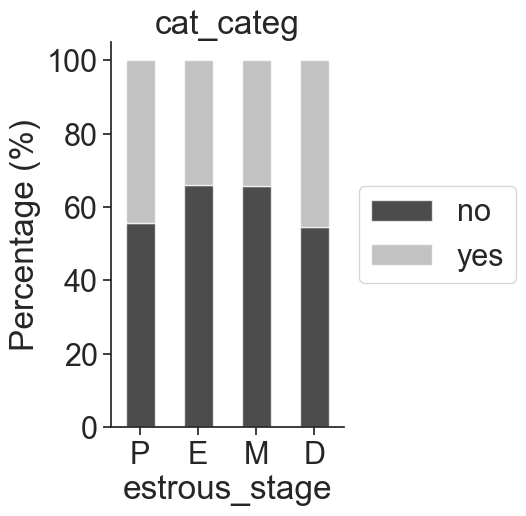

-0.012961754679172627 0.9870382453208273


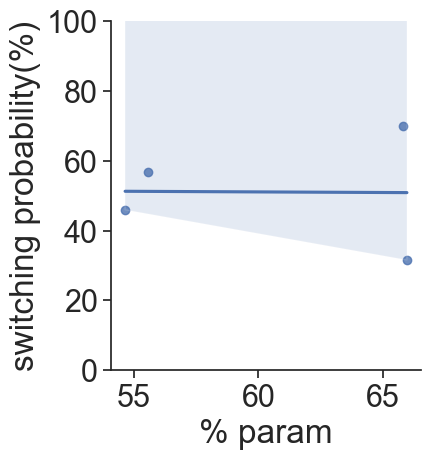

IH              no  yes  All
estrous_stage               
?                0    8    8
D               23   63   86
D to P           1    3    4
E               11   36   47
M               18   20   38
P                5   22   27
P to E           3    3    6
not taken        4    4    8
to be stained   16   46   62
All             81  205  286
0.05266793974917148
IH estrous_stage         no        yes
5              P  18.518519  81.481481
3              E  23.404255  76.595745
4              M  47.368421  52.631579
1              D  26.744186  73.255814


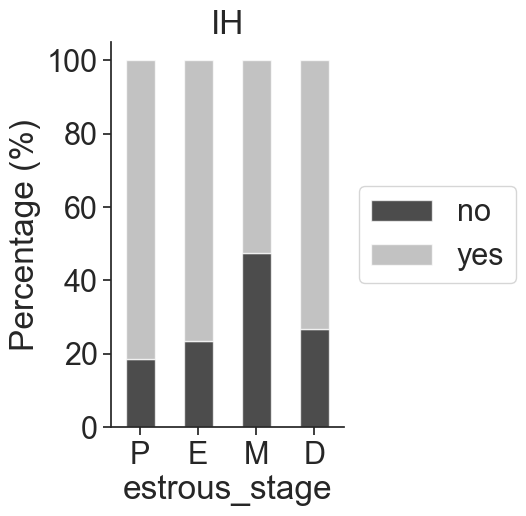

0.6603368029520499 0.3396631970479502


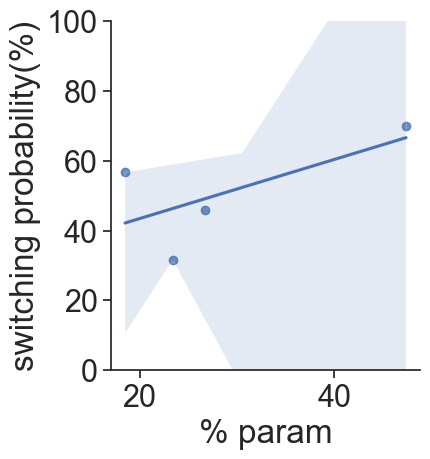

Adaptive        ?  no  yes  All
estrous_stage                  
?               0   0    2    2
D               0  21   27   48
D to P          0   3    1    4
E               0   8   27   35
M               0  18   17   35
P               2   4   11   17
P to E          1   1    4    6
to be stained   1  24   16   41
All             4  79  105  188
0.002278115864816145
Adaptive estrous_stage         no        yes
5                    P  23.529412  64.705882
3                    E  22.857143  77.142857
4                    M  51.428571  48.571429
1                    D  43.750000  56.250000


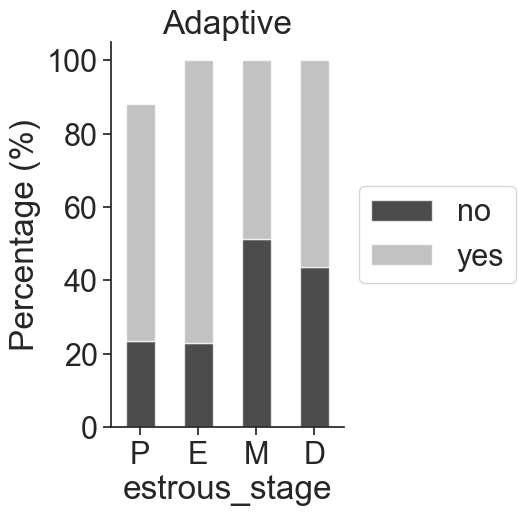

0.6220659380285585 0.3779340619714415


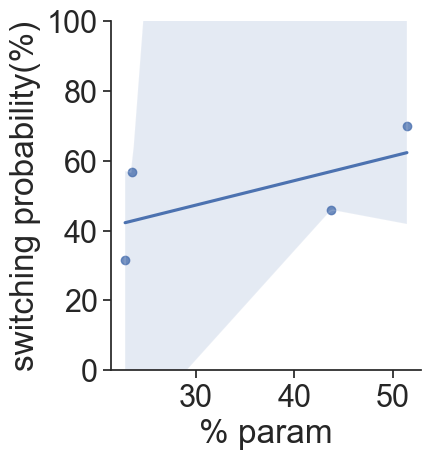

In [11]:
import scipy as sp
cols = ['no', 'yes']
ephys.loc[(ephys['Ih_at_-120mV'] == 0), 'IH']  = 'no'
ephys.loc[(ephys['Ih_at_-120mV'] >0 ), 'IH']  = 'yes'


estrous_df = pd.read_csv('../NPS_behaviour_analysis/generated_datasets/estrous_data.csv')
estrous_df.rename(columns = {'Unnamed: 0':'estrous_stage', '0':'switching probability'}, inplace = True)
ephys_pre = ephys[ephys.Behaviour_6hFD == 'Pre']

for column in ['cat_categ', 'IH', 'Adaptive']:
    esprop = proportion(ephys_pre, 'estrous_stage', column, cols)
    esprop['estrous_stage'] = pd.Categorical(esprop['estrous_stage'], ['P', 'E', 'M', 'D'])
    esprop = esprop.sort_values(by = ['estrous_stage']).dropna()
    prop_plot(esprop, 'estrous_stage')
    print(esprop)
    plt.title(column)
    plt.show()

    corr = pd.merge(esprop, estrous_df, on = 'estrous_stage')
    r, p = sp.stats.pearsonr(corr['switching probability'], corr['no'])
    print(r, p)

    sns.lmplot(x = 'no', y = 'switching probability', data = corr)
    plt.ylim([0, 100])
    plt.xlabel('% param')
    plt.ylabel('switching probability(%)')
    plt.show()

# npy administration

In [97]:
def pairline_plot(y, data):
    plt.subplots(figsize = (1.5,2))
    sns.lineplot(x = 'condition', y = y, hue = 'cell_id',data = data, palette = ['Tab:red'], alpha = 0.8)
    sns.swarmplot(x = 'condition', y = y ,data = data, palette = ['Tab:red'], alpha = 0.8)
    sns.boxplot(x = 'condition', y = y,data = data, palette = ['Tab:red'],boxprops=dict(alpha=.5), width = 0.5)
    ax = plt.gca()
    ax.get_legend().remove()
    sns.despine()
    plt.xticks(rotation = 90)
    plt.xlabel('')
    plt.show()

def sub_datset(data):

    vm = data.melt(id_vars=['cell_id'], value_vars=['Vm_control', 'Vm_drug'], var_name='condition', value_name='Vm')
    ir = data.melt(id_vars=['cell_id'], value_vars=['IR_control', 'IR_drug'], var_name='condition', value_name='IR')
    ih = data.melt(id_vars=['cell_id'], value_vars=['Ih_control', 'Ih_drug'], var_name='condition', value_name='Ih')
    fr = data.melt(id_vars=['cell_id'], value_vars=['firing_freq_control', 'firing_freq_drug'], var_name='condition', value_name='firing_freq')

    return [vm, ir, ih, fr]
    

100npy


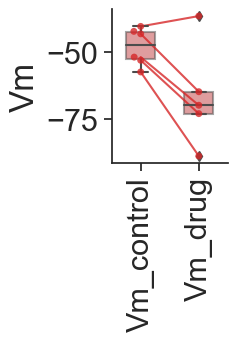

100npy


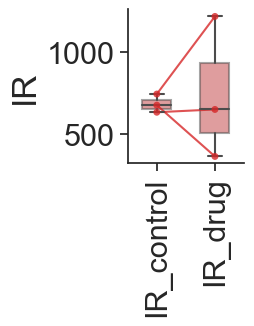

100npy


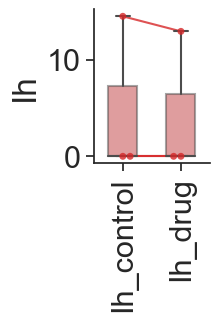

100npy


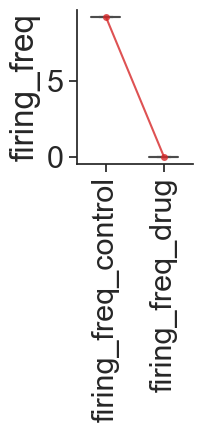

10npy


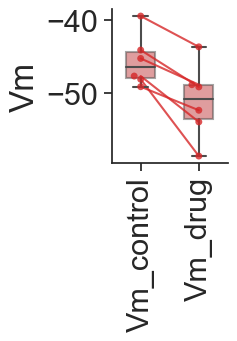

10npy


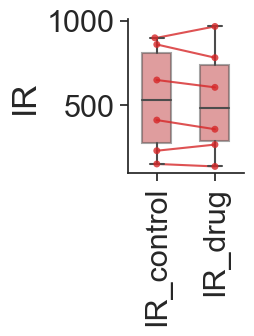

10npy


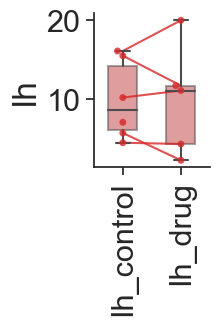

10npy


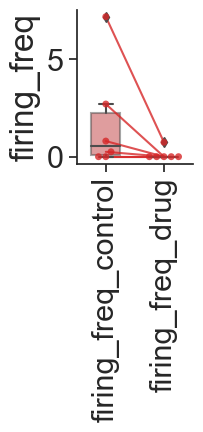

In [98]:
df = pd.read_csv('pharmacology.csv')
df['drug'] = df.conc_nM.astype(str) + df.identity


for drug in df.drug.unique()[:-1]:
    drug_df = df[df.drug == drug]
    df_list = sub_datset(drug_df)

    for subdata in df_list:
        
        subdata  = subdata.dropna()
        if len(subdata.condition.unique()) <2:
            continue
        else:
            print(drug)
            pairline_plot(str(subdata.columns[2]), subdata)